# training_viz2.ipynb — Figures for Thesis §3.3

New figures (not covered by `training_viz.ipynb`):
- **Fig 3.1** — val/loss learning curves, full mapper_only grid
- **Fig 3.4** — val/loss learning curves, full full_ft grid
- **Fig 3.8** — MLP / MLP-36M / TransformerMapper complexity ablation
- **PEFT** — map_only vs LoRA vs soft-prompt
- **LLM scaling** — 0.6B vs 4B vs 8B

Reusable from `training_viz.ipynb` (`artefacts/figures/`):
- Fig 3.2 → `3_4_bleu_vs_k_all_mappers_map_only.png`
- Fig 3.3 → `3_5_rouge_vs_k_all_mappers_map_only.png`
- Fig 3.5 → `3_6_bleu_vs_k_all_mappers_full_ft.png`
- Fig 3.6 → `3_7_rouge_vs_k_all_mappers_full_ft.png`

In [26]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

BASE      = Path("/Users/kirill/My Folder/study/thesis/all_code_and_stuff")
DATA_PATH = BASE / "artefacts/tb_metrics_export (1).csv"
FIG_DIR   = BASE / "artefacts/figures_v2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PLT_STYLE  = "seaborn-v0_8-whitegrid"
DPI        = 300
FONT_TITLE = 14
FONT_LABEL = 12
FONT_TICK  = 11

C_LINEAR = "#4C72B0"
C_MLP    = "#DD8452"
C_TM     = "#55A868"
C_MLP36M = "#E377C2"

MAPPER_COLORS  = {"Linear": C_LINEAR, "MLP": C_MLP, "MLP-36M": C_MLP36M, "TransformerMapper": C_TM}
MAPPER_MARKERS = {"Linear": "o",      "MLP": "s",   "MLP-36M": "D",       "TransformerMapper": "^"}
MAPPER_LS      = {"Linear": "-",      "MLP": "--",  "MLP-36M": ":",       "TransformerMapper": "-."}

CONFIG_COLORS = {
    "map_only":    "#AEC6E8",
    "map+LoRA":    "#DD8452",
    "soft-prompt": "#9467BD",
    "full_ft":     "#7B2D8B",
}

K_VALUES  = [1, 4, 8, 16, 32]
K_COLORS  = {1: "#C6DBEF", 4: "#9ECAE1", 8: "#6BAED6", 16: "#2171B5", 32: "#08306B"}
K_MARKERS = {1: "o", 4: "s", 8: "^", 16: "D", 32: "*"}
K_LS      = {1: "-", 4: "--", 8: "-.", 16: ":", 32: (0, (3, 1, 1, 1, 1, 1))}
MAX_VAL_STEPS = 4

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.linewidth":    0.5,
    "grid.alpha":        0.6,
    "legend.frameon":    True,
    "legend.framealpha": 1.0,
    "legend.facecolor":  "white",
    "legend.edgecolor":  "#aaaaaa",
    "legend.fontsize":   FONT_TICK,
})

def save_fig(fig, name):
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=DPI, bbox_inches="tight")
    print(f"  -> {name}.png / .pdf")

print("Стиль настроен. FIG_DIR:", FIG_DIR)

Стиль настроен. FIG_DIR: /Users/kirill/My Folder/study/thesis/all_code_and_stuff/artefacts/figures_v2


In [27]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Загружено {len(df_raw):,} строк, {df_raw['run_name'].nunique()} экспериментов")

def get_curve(run, metric="val/loss", max_steps=MAX_VAL_STEPS):
    """Returns (val_step_indices [1..N], values), clipped to max_steps."""
    sub = df_raw[(df_raw["run_name"] == run) & (df_raw["metric"] == metric)].sort_values("step")
    if sub.empty:
        return None, None
    sub = sub.iloc[:max_steps]
    return np.arange(1, len(sub) + 1), sub["value"].values

def final_metric(run, metric):
    """Value at the 4th validation step (epoch-1 comparable)."""
    sub = df_raw[(df_raw["run_name"] == run) & (df_raw["metric"] == metric)].sort_values("step")
    sub = sub.iloc[:MAX_VAL_STEPS]
    return float(sub["value"].iloc[-1]) if not sub.empty else np.nan

MAPPER_ONLY_RUNS = {
    "Linear": {
        1:  "lin_ctx1_mapper_only",
        4:  "lin_ctx4_mapper_only",
        8:  "lin_ctx8_mapper_only",
        16: "lin_ctx16_mapper_only",
    },
    "MLP": {
        1:  "mlp_ctx1_mapper_only",
        4:  "mlp_ctx4_mapper_only",
        8:  "mlp_ctx8_mapper_only",
        16: "mlp_ctx16_mapper_only",
    },
    "TransformerMapper": {
        1:  "perceiver_ctx1_mapper_only",
        4:  "perceiver_ctx4_mapper_only",
        8:  "perceiver_ctx8_mapper_only",
        16: "perceiver_ctx16_mapper_only",
        32: "perceiver_ctx32_mapper_only",
    },
}

FULL_FT_RUNS = {
    "Linear": {
        1:  "lin_ctx1_full_ft",
        8:  "lin_ctx8_full_ft",
        16: "lin_ctx16_full_ft",
    },
    "MLP": {
        1:  "mlp_ctx1_full_ft",
        8:  "mlp_ctx8_full_ft",
        16: "mlp_ctx16_full_ft",
    },
    "TransformerMapper": {
        16: "perceiver_ctx16_full_ft",
    },
}

# Sanity check
print("\nПроверка (clip_steps=4):")
for run in ["perceiver_ctx16_mapper_only", "perceiver_ctx16_full_ft"]:
    b = final_metric(run, "val/narrative/bleu@64")
    r = final_metric(run, "val/qa/rougeL@64")
    print(f"  {run:40s}  BLEU@64={b:.3f}  ROUGE-L@64={r:.3f}")

Загружено 807,746 строк, 28 экспериментов

Проверка (clip_steps=4):
  perceiver_ctx16_mapper_only               BLEU@64=0.171  ROUGE-L@64=0.112
  perceiver_ctx16_full_ft                   BLEU@64=0.743  ROUGE-L@64=0.418


## Рисунок 3.1 — val/loss, полная сетка mapper_only

3 подграфика (Linear | MLP | TransformerMapper). В каждом — кривая обучения для каждого k.
Все серии различаются и цветом, и маркером, и стилем линии → читаемо при ч/б печати.

  -> fig3_1_valloss_mapper_only_grid.png / .pdf


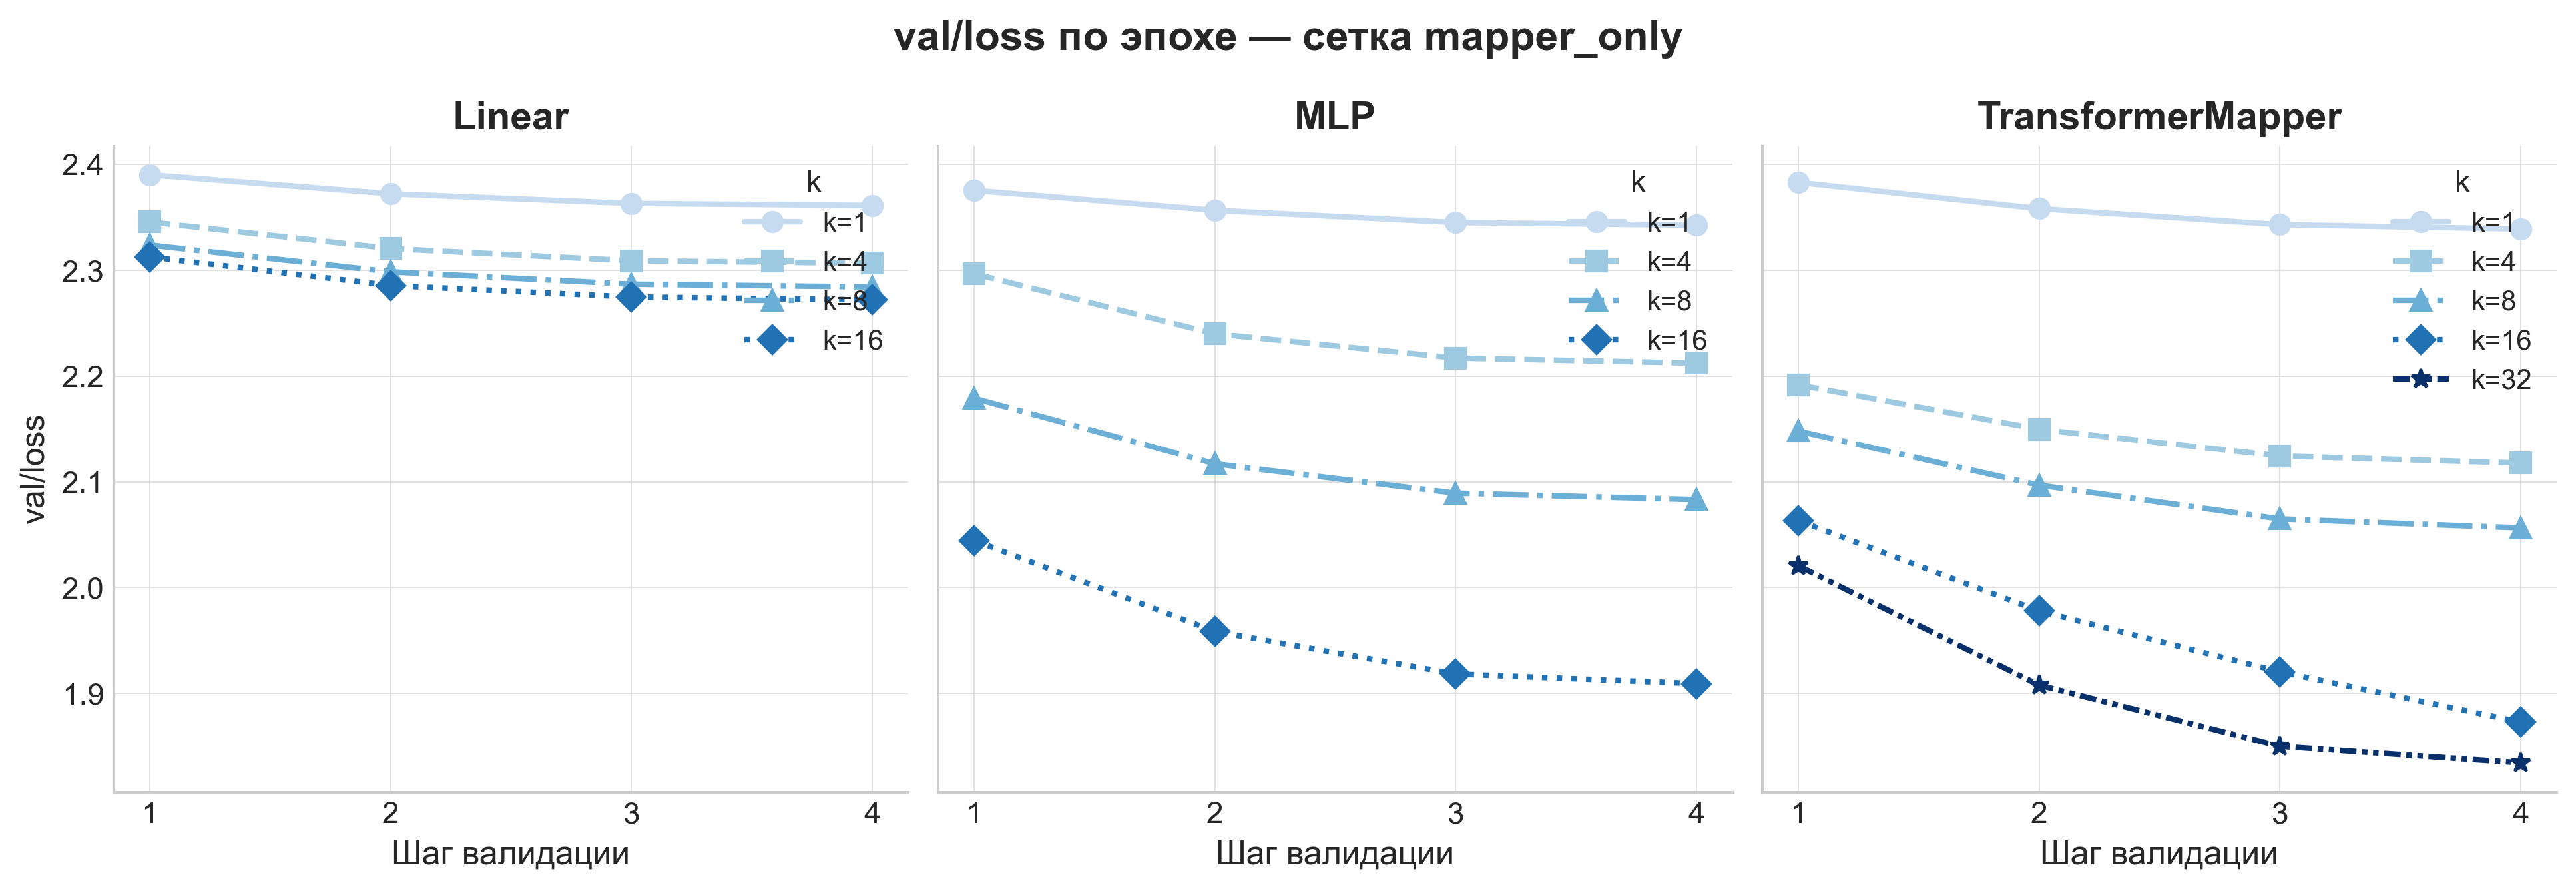

In [3]:
with plt.style.context(PLT_STYLE):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True, dpi=DPI)

    for ax, (mapper, k_runs) in zip(axes, MAPPER_ONLY_RUNS.items()):
        for k in sorted(k_runs):
            run = k_runs[k]
            xs, ys = get_curve(run, "val/loss")
            if xs is None:
                continue
            ax.plot(xs, ys,
                    color=K_COLORS[k], linestyle=K_LS[k],
                    marker=K_MARKERS[k], markersize=7, linewidth=2,
                    label=f"k={k}", zorder=5)
        ax.set_title(mapper, fontsize=FONT_TITLE, fontweight="bold")
        ax.set_xlabel("Шаг валидации", fontsize=FONT_LABEL)
        if ax is axes[0]:
            ax.set_ylabel("val/loss", fontsize=FONT_LABEL)
        ax.set_xticks([1, 2, 3, 4])
        ax.tick_params(labelsize=FONT_TICK)
        ax.legend(title="k", fontsize=FONT_TICK - 1, title_fontsize=FONT_TICK,
                  loc="upper right")

    fig.suptitle("val/loss по эпохе — сетка mapper_only",
                 fontsize=FONT_TITLE + 1, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "fig3_1_valloss_mapper_only_grid")
    plt.show()

## Рисунок 3.2 — BLEU@64 vs k, все маппер, map_only

  -> fig3_2_bleu_vs_k_map_only.png / .pdf


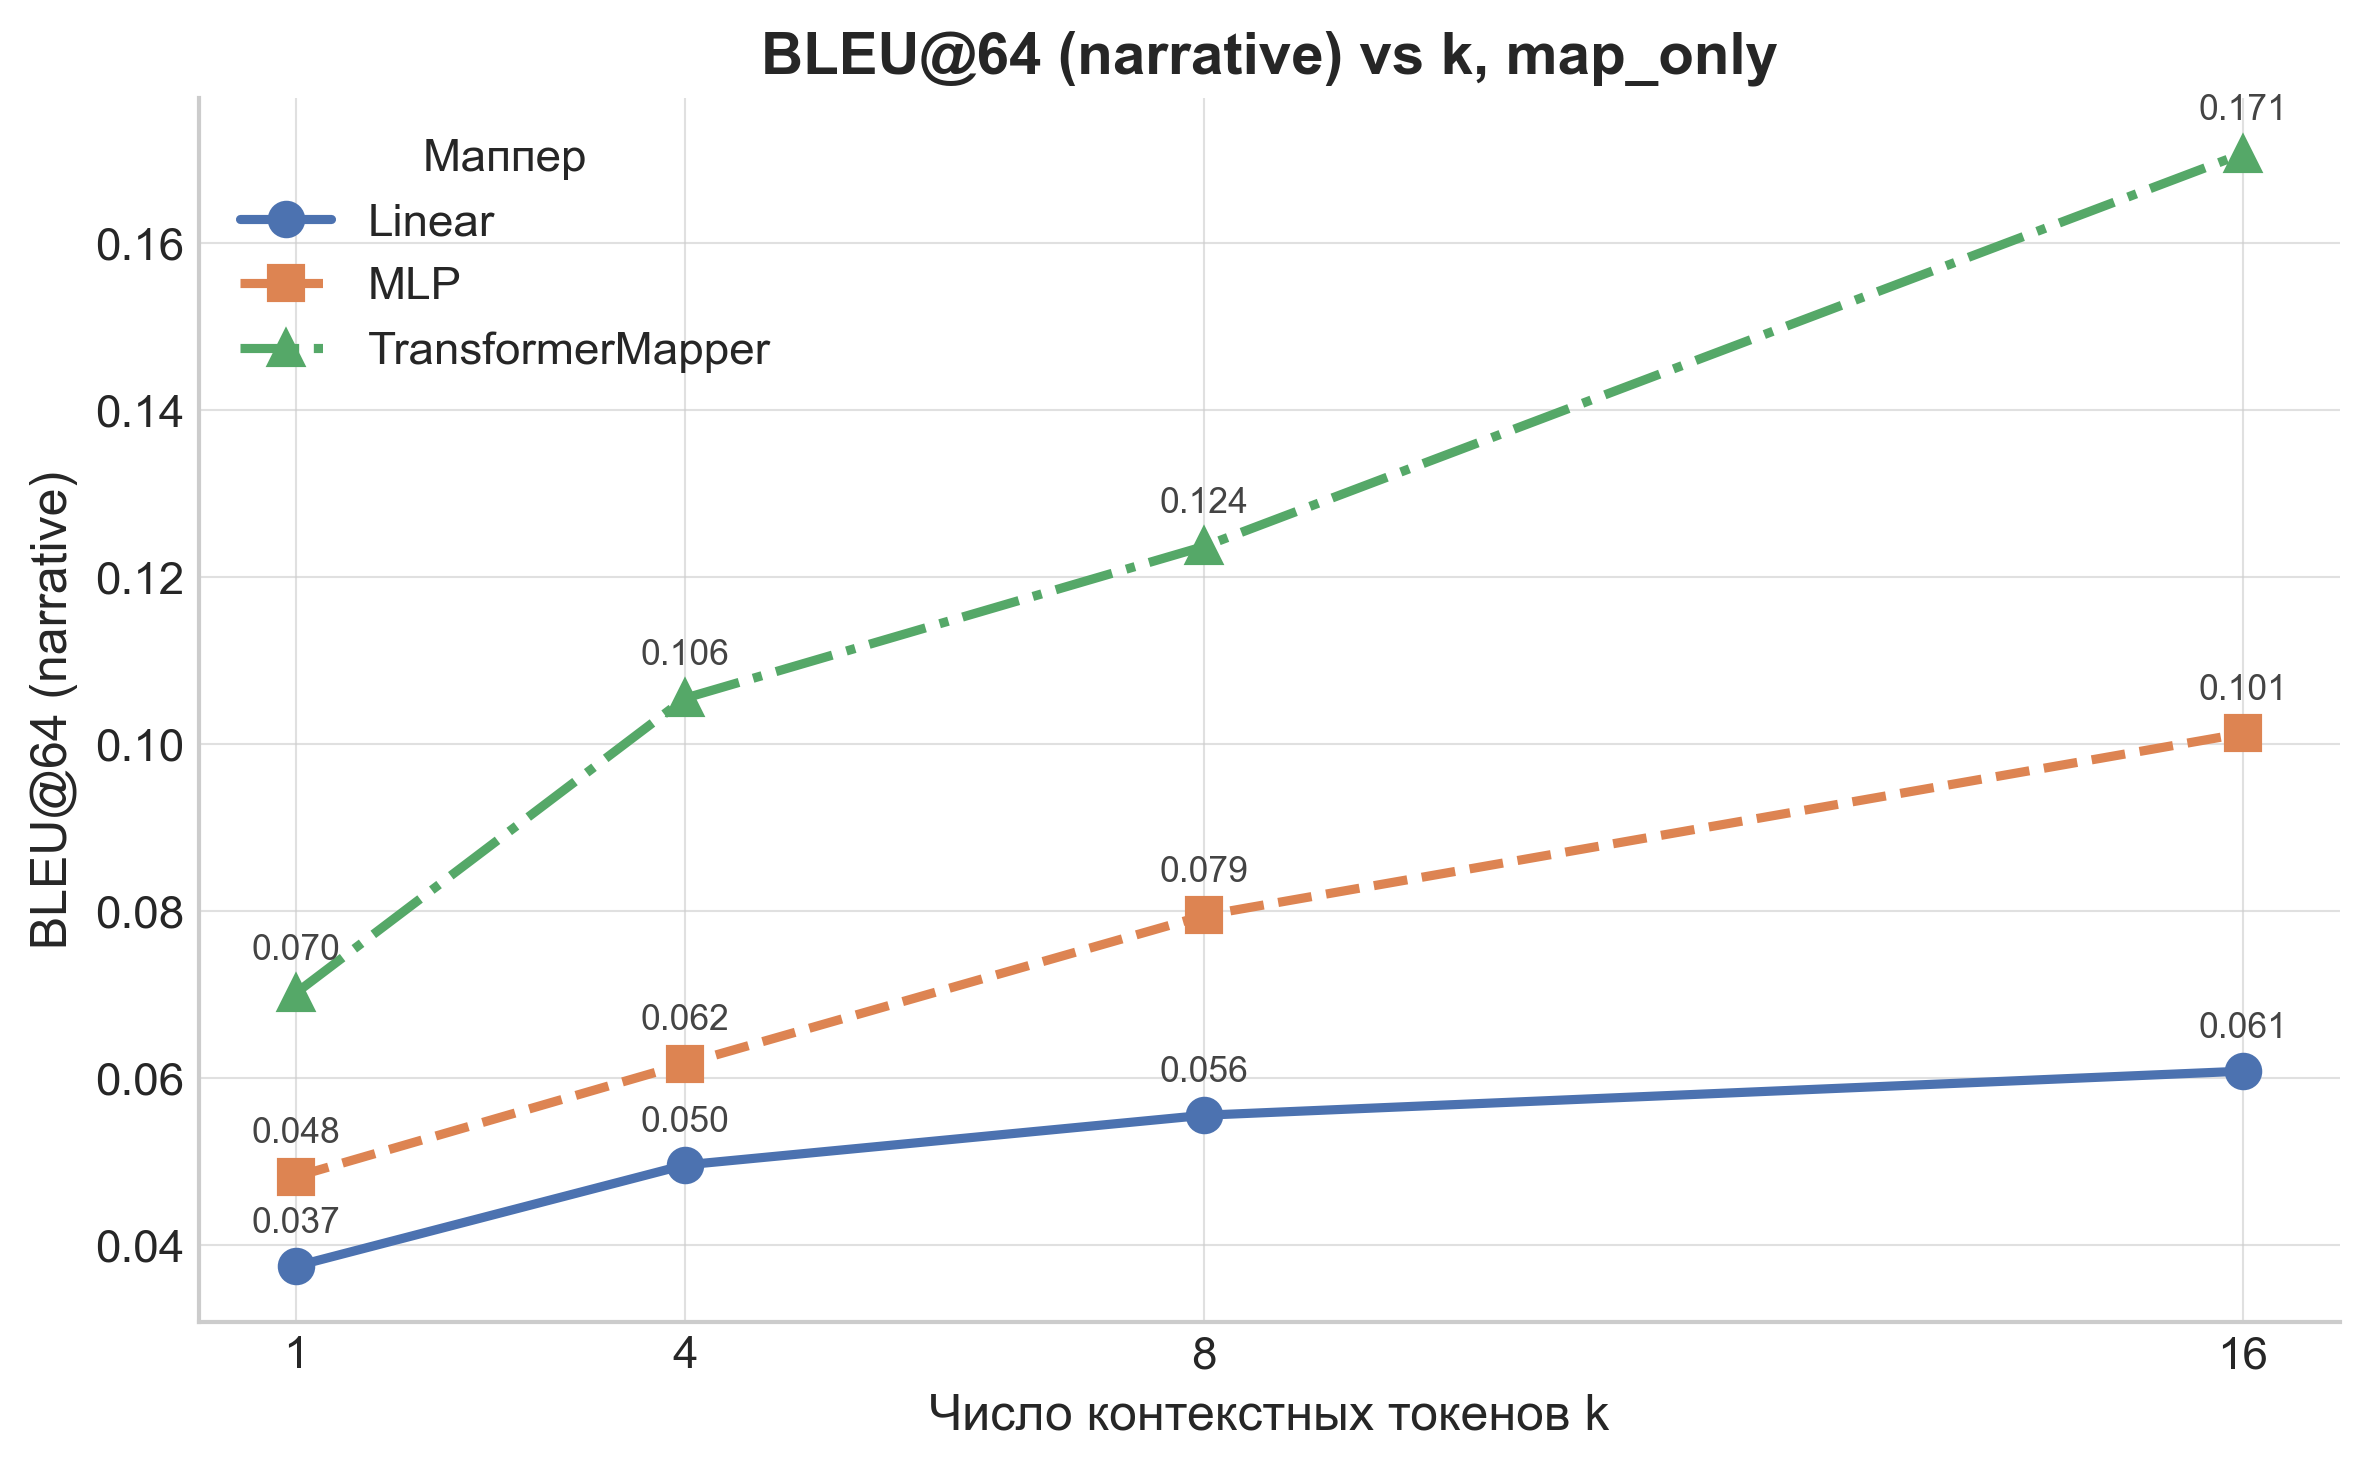

In [31]:
map_only_k = {
    "Linear":            [1, 4, 8, 16],
    "MLP":               [1, 4, 8, 16],
    "TransformerMapper": [1, 4, 8, 16],
}

with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)
    for mapper, ks in map_only_k.items():
        vals = [final_metric(MAPPER_ONLY_RUNS[mapper][k], "val/narrative/bleu@64")
                for k in ks]
        pts = [(k, v) for k, v in zip(ks, vals) if not np.isnan(v)]
        if not pts:
            continue
        kk, vv = zip(*pts)
        ax.plot(kk, vv,
                color=MAPPER_COLORS[mapper], linewidth=2.2,
                marker=MAPPER_MARKERS[mapper], markersize=8,
                linestyle=MAPPER_LS[mapper], label=mapper)
        for k, v in zip(kk, vv):
            ax.annotate(f"{v:.3f}", (k, v), xytext=(0, 8),
                        textcoords="offset points", ha="center", fontsize=8.5, color="#444")

    ax.set_xticks([1, 4, 8, 16])
    ax.set_xlabel("Число контекстных токенов k", fontsize=FONT_LABEL)
    ax.set_ylabel("BLEU@64 (narrative)", fontsize=FONT_LABEL)
    ax.set_title("BLEU@64 (narrative) vs k, map_only",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(title="Маппер", fontsize=FONT_TICK, title_fontsize=FONT_TICK, loc="upper left")
    plt.tight_layout()
    save_fig(fig, "fig3_2_bleu_vs_k_map_only")
    plt.show()

## Рисунок 3.3 — ROUGE-L@64 vs k, все маппер, map_only

  -> fig3_3_rouge_vs_k_map_only.png / .pdf


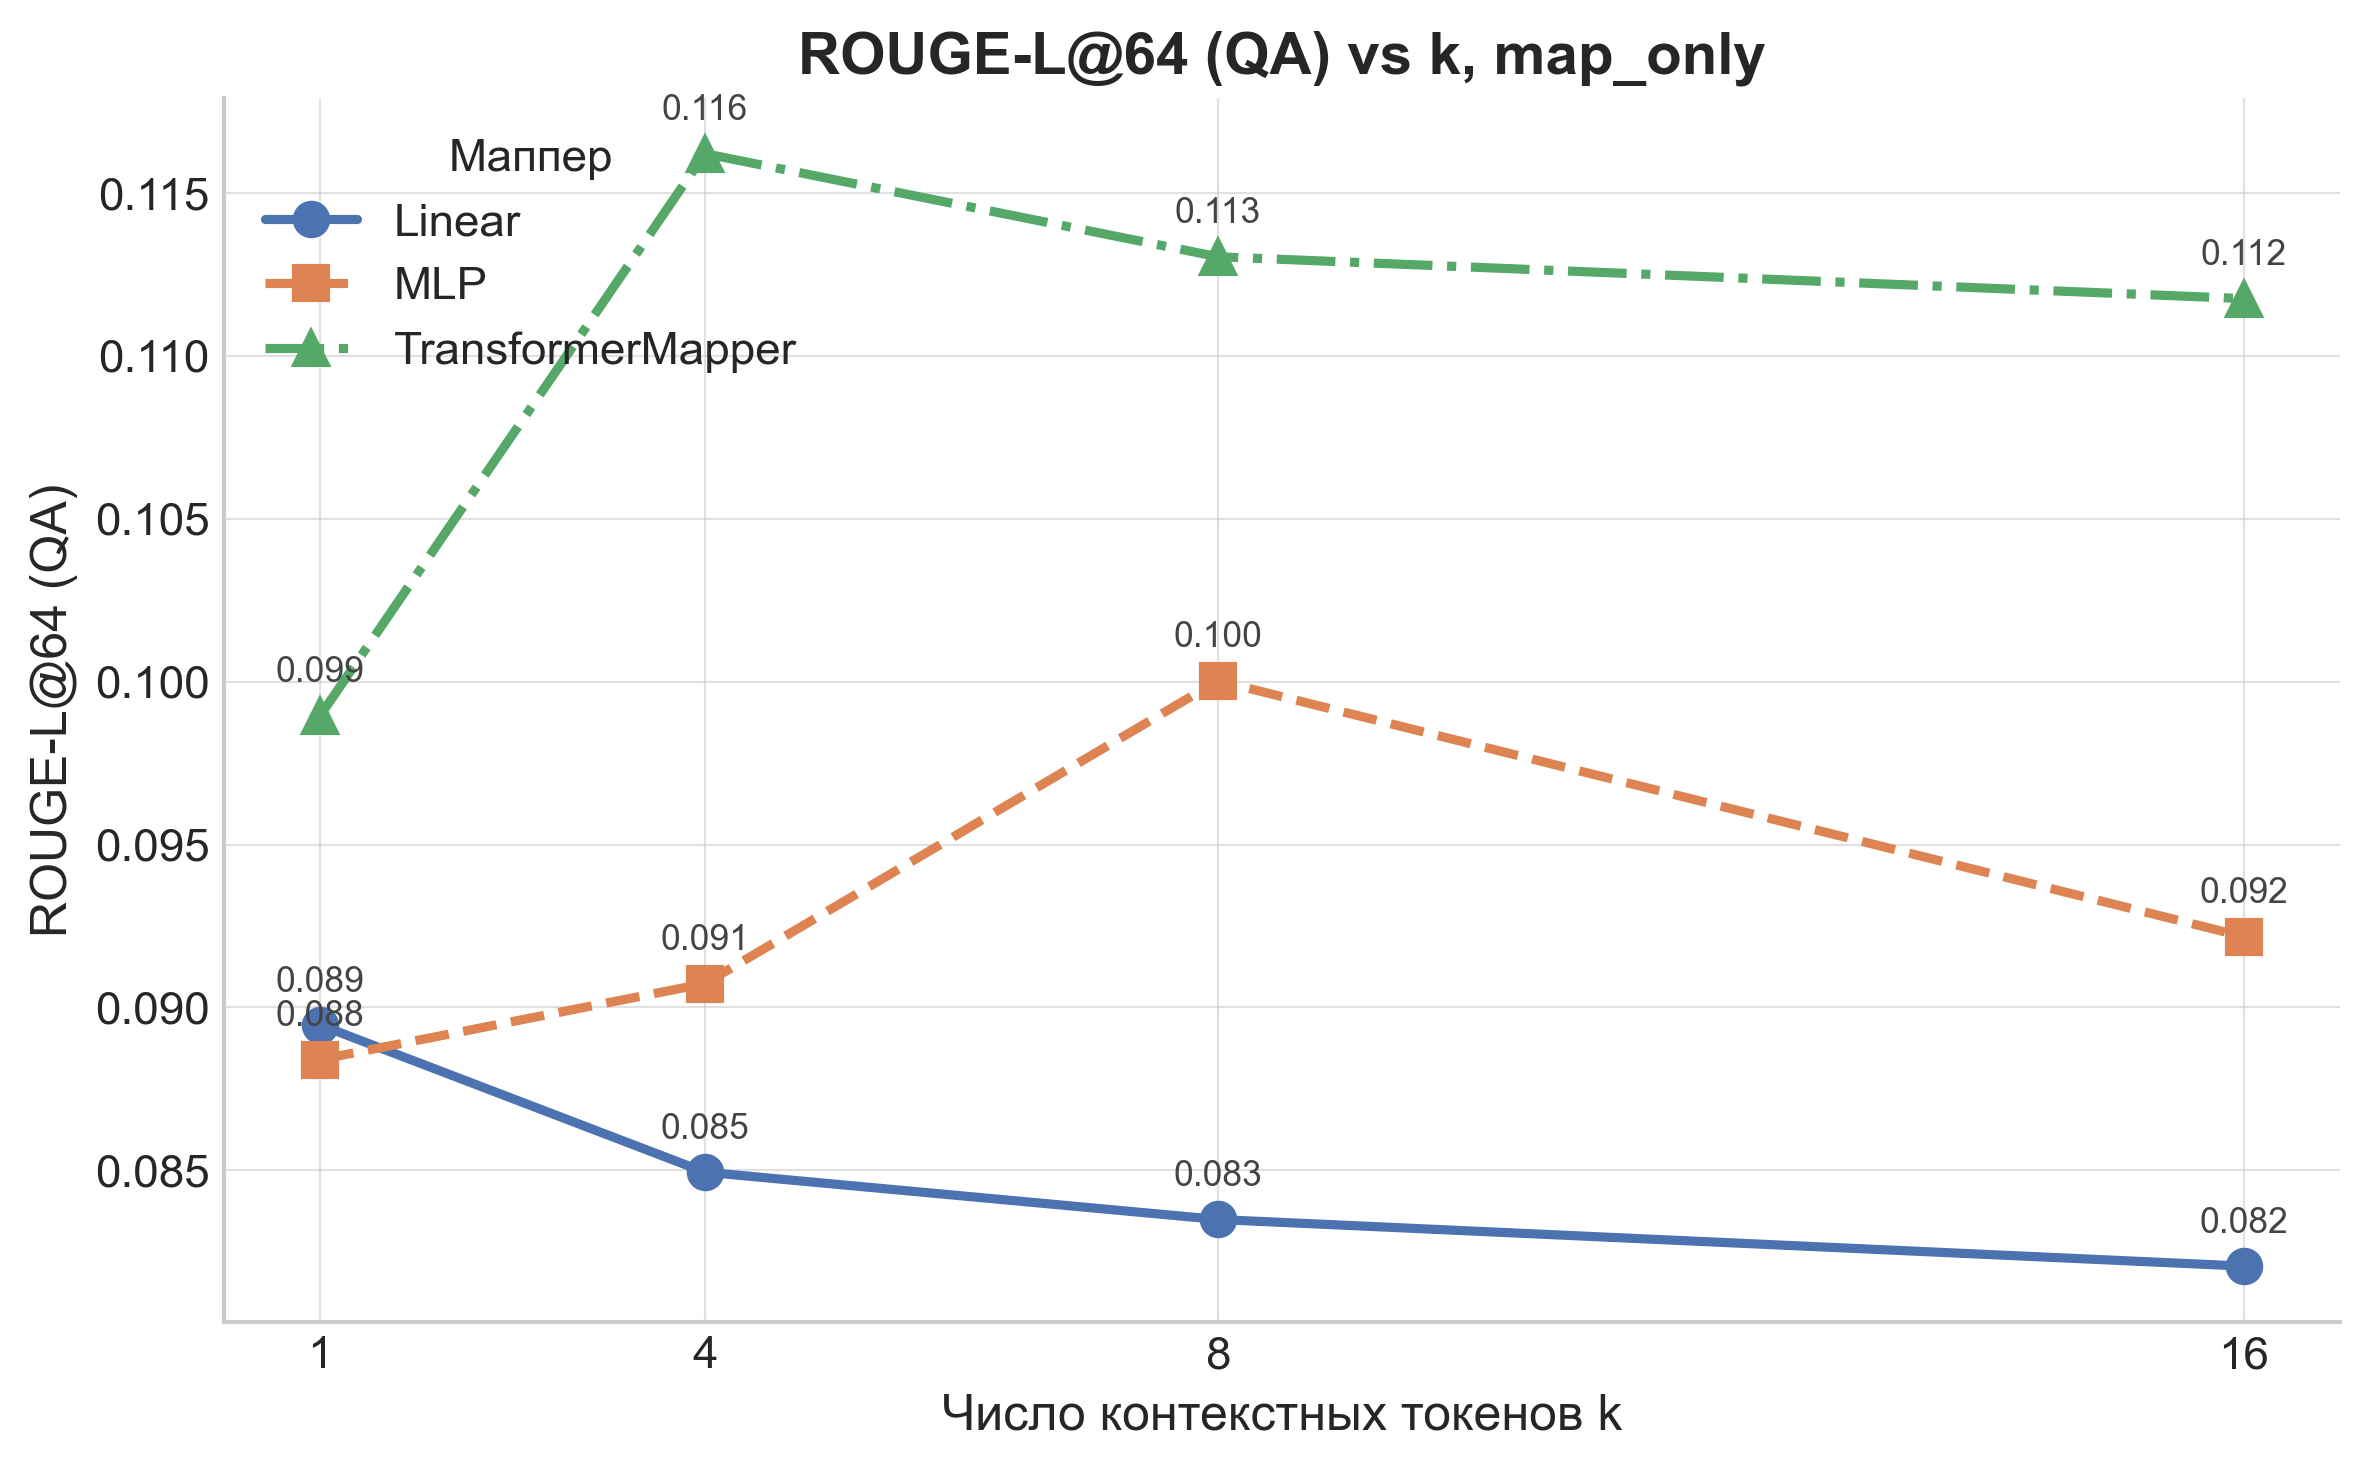

In [30]:
with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)
    for mapper, ks in map_only_k.items():
        vals = [final_metric(MAPPER_ONLY_RUNS[mapper][k], "val/qa/rougeL@64")
                for k in ks]
        pts = [(k, v) for k, v in zip(ks, vals) if not np.isnan(v)]
        if not pts:
            continue
        kk, vv = zip(*pts)
        ax.plot(kk, vv,
                color=MAPPER_COLORS[mapper], linewidth=2.2,
                marker=MAPPER_MARKERS[mapper], markersize=8,
                linestyle=MAPPER_LS[mapper], label=mapper)
        for k, v in zip(kk, vv):
            ax.annotate(f"{v:.3f}", (k, v), xytext=(0, 8),
                        textcoords="offset points", ha="center", fontsize=8.5, color="#444")

    ax.set_xticks([1, 4, 8, 16])
    ax.set_xlabel("Число контекстных токенов k", fontsize=FONT_LABEL)
    ax.set_ylabel("ROUGE-L@64 (QA)", fontsize=FONT_LABEL)
    ax.set_title("ROUGE-L@64 (QA) vs k, map_only",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(title="Маппер", fontsize=FONT_TICK, title_fontsize=FONT_TICK, loc="upper left")
    plt.tight_layout()
    save_fig(fig, "fig3_3_rouge_vs_k_map_only")
    plt.show()

## Рисунок 3.4 — val/loss при k=16, сравнение всех трёх маппер-архитектур (full_ft)

In [ ]:
# Fig 3.4 — val/loss при k=16: сравнение Linear / MLP / TransformerMapper, full_ft
# Одна панель, три линии — самое чистое сравнение архитектур маппера

k16_full_ft = [
    ("lin_ctx16_full_ft",       "Linear"),
    ("mlp_ctx16_full_ft",       "MLP"),
    ("perceiver_ctx16_full_ft", "TransformerMapper"),
]

with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)

    for run, mapper in k16_full_ft:
        xs, ys = get_curve(run, "val/loss")
        if xs is None:
            continue
        ax.plot(xs, ys,
                color=MAPPER_COLORS[mapper],
                linestyle=MAPPER_LS[mapper],
                marker=MAPPER_MARKERS[mapper],
                markersize=8, linewidth=2.2,
                label=mapper, zorder=5)
        for x, y in zip(xs, ys):
            ax.annotate(f"{y:.3f}", (x, y), xytext=(0, 9),
                        textcoords="offset points", ha="center",
                        fontsize=8.5, color="#444")

    ax.set_xticks([1, 2, 3, 4])
    ax.set_xlabel("Шаг валидации", fontsize=FONT_LABEL)
    ax.set_ylabel("val/loss", fontsize=FONT_LABEL)
    ax.set_title("val/loss по эпохе — full_ft, k=16",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(title="Маппер", fontsize=FONT_TICK, title_fontsize=FONT_TICK)
    plt.tight_layout()
    save_fig(fig, "fig3_4_valloss_full_ft_k16")
    plt.show()

## Рисунок 3.4б — val/loss по k: Linear и MLP, full_ft (k=1, 8, 16)

Дополнительный график: как меняется лосс с ростом k при full_ft для двух маппер.
TransformerMapper здесь не показан — только k=16.

In [ ]:
# Fig 3.4б — val/loss curves по k, Linear и MLP, full_ft
# 2 субплота (sharey=True), k=1/8/16, линии по K_COLORS + K_MARKERS + K_LS

lin_mlp_full_ft = {
    "Linear": {1: "lin_ctx1_full_ft", 8: "lin_ctx8_full_ft", 16: "lin_ctx16_full_ft"},
    "MLP":    {1: "mlp_ctx1_full_ft", 8: "mlp_ctx8_full_ft", 16: "mlp_ctx16_full_ft"},
}

with plt.style.context(PLT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True, dpi=DPI)

    for ax, (mapper, k_runs) in zip(axes, lin_mlp_full_ft.items()):
        for k in sorted(k_runs):
            run = k_runs[k]
            xs, ys = get_curve(run, "val/loss")
            if xs is None:
                continue
            ax.plot(xs, ys,
                    color=K_COLORS[k], linestyle=K_LS[k],
                    marker=K_MARKERS[k], markersize=7, linewidth=2,
                    label=f"k={k}", zorder=5)
        ax.set_title(mapper, fontsize=FONT_TITLE, fontweight="bold")
        ax.set_xlabel("Шаг валидации", fontsize=FONT_LABEL)
        if ax is axes[0]:
            ax.set_ylabel("val/loss", fontsize=FONT_LABEL)
        ax.set_xticks([1, 2, 3, 4])
        ax.tick_params(labelsize=FONT_TICK)
        ax.legend(title="k", fontsize=FONT_TICK - 1, title_fontsize=FONT_TICK,
                  loc="upper right")

    fig.suptitle("val/loss по k — Linear и MLP, full_ft",
                 fontsize=FONT_TITLE + 1, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "fig3_4b_valloss_lin_mlp_full_ft_kscaling")
    plt.show()

## Рисунок 3.5а — Барчарт: все три маппера при k=16, full_ft (BLEU@64 и ROUGE-L@64)

  -> fig3_5a_bar_fullft_k16_mappers.png / .pdf


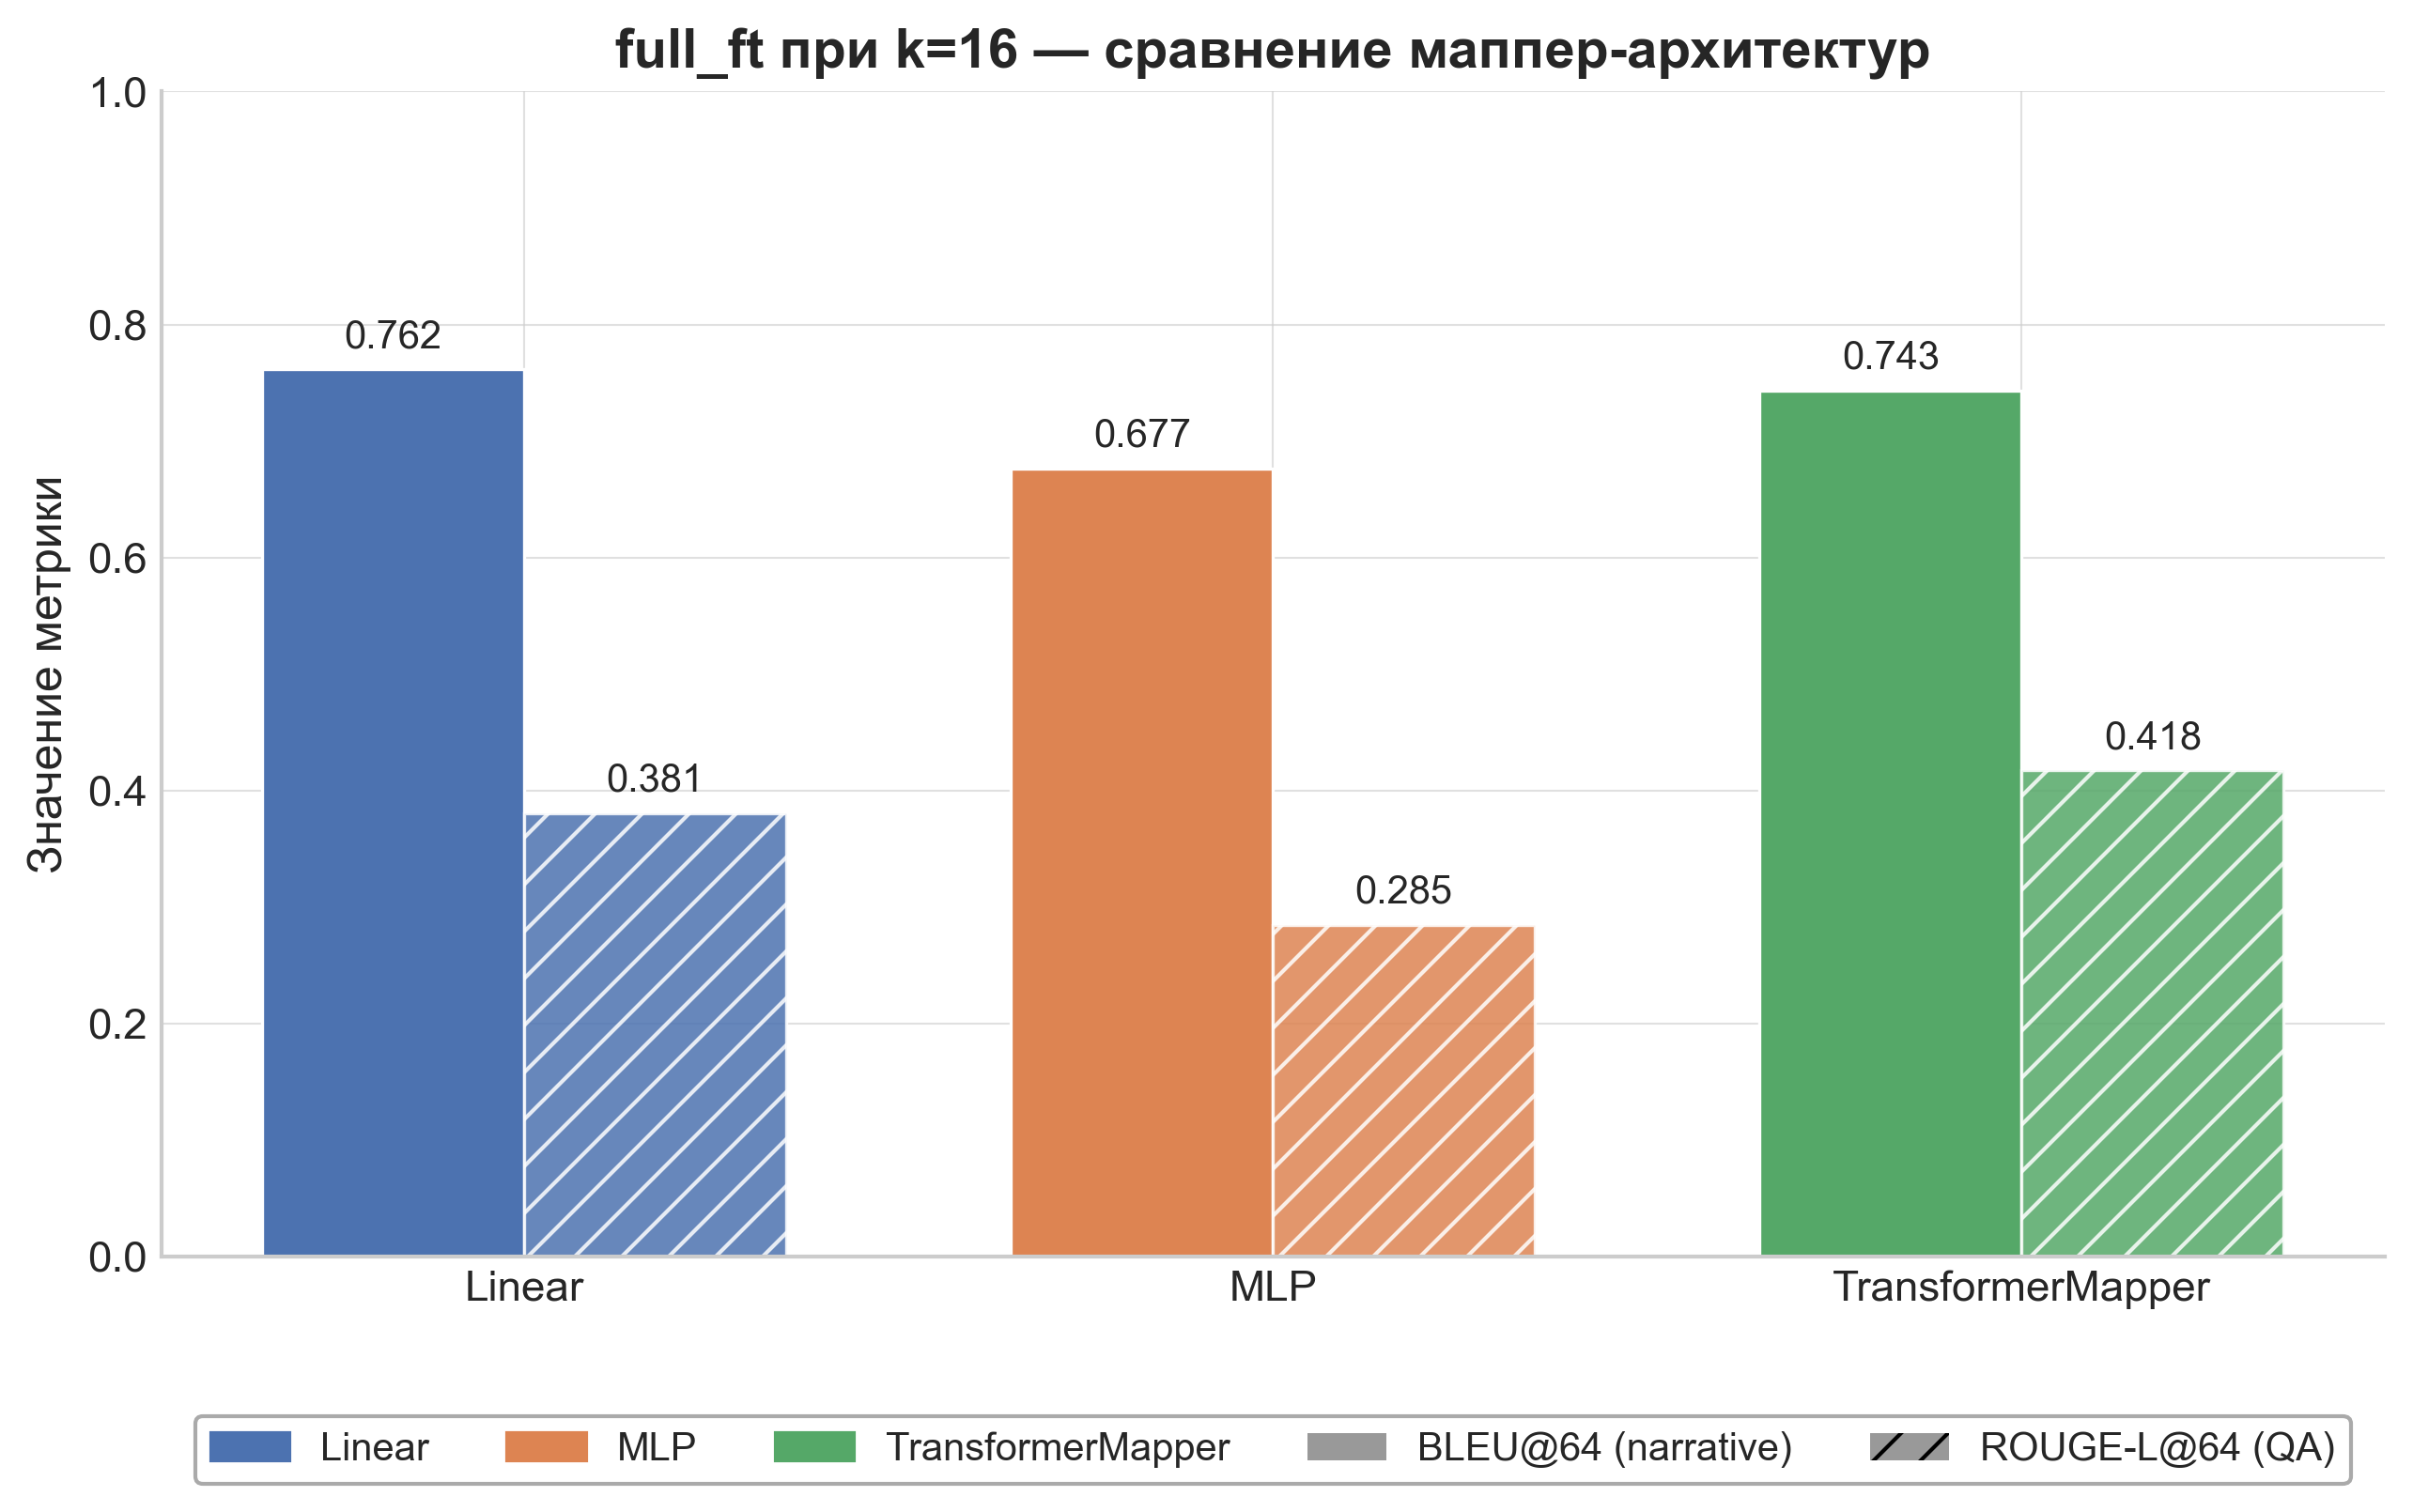

In [23]:
mappers_k16 = [
    ("Linear",            "lin_ctx16_full_ft"),
    ("MLP",               "mlp_ctx16_full_ft"),
    ("TransformerMapper", "perceiver_ctx16_full_ft"),
]
metrics_bar = [
    ("val/narrative/bleu@64", "BLEU@64 (narrative)", ""),
    ("val/qa/rougeL@64",      "ROUGE-L@64 (QA)",     "//"),
]

x_b = np.arange(len(mappers_k16))
w_b = 0.35

with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=DPI)

    for i, (metric_key, metric_label, hatch) in enumerate(metrics_bar):
        vals   = [final_metric(run, metric_key) for _, run in mappers_k16]
        offset = (i - 0.5) * w_b
        bars   = ax.bar(x_b + offset, vals, w_b,
                        label=metric_label,
                        color=[MAPPER_COLORS[m] for m, _ in mappers_k16],
                        hatch=hatch, edgecolor="white", linewidth=0.8,
                        alpha=0.85 if hatch else 1.0)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{v:.3f}", ha="center", va="bottom",
                        fontsize=FONT_TICK - 1)

    ax.set_ylim(0, 1.0)
    ax.set_xticks(x_b)
    ax.set_xticklabels([m for m, _ in mappers_k16], fontsize=FONT_TICK)
    ax.set_ylabel("Значение метрики", fontsize=FONT_LABEL)
    ax.set_title("full_ft при k=16 — сравнение маппер-архитектур",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)

    # Обе легенды — горизонтально под осью, не перекрывают бары
    mapper_handles = [mpatches.Patch(color=MAPPER_COLORS[m], label=m)
                      for m, _ in mappers_k16]
    metric_handles = [
        mpatches.Patch(facecolor="#999", hatch="",   label="BLEU@64 (narrative)"),
        mpatches.Patch(facecolor="#999", hatch="//", label="ROUGE-L@64 (QA)"),
    ]
    ax.legend(handles=mapper_handles + metric_handles,
              ncol=5, fontsize=FONT_TICK - 1,
              loc="upper center", bbox_to_anchor=(0.5, -0.12),
              frameon=True, facecolor="white", edgecolor="#aaaaaa")

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.18)
    save_fig(fig, "fig3_5a_bar_fullft_k16_mappers")
    plt.show()

## Рисунок 3.5б — Линейные и MLP маппер: рост метрик с k при full_ft (k=1, 8, 16)

Два субплота: левый — BLEU@64 (narrative), правый — ROUGE-L@64 (QA).
TransformerMapper не включён — только k=16, одна точка не даёт кривой.

  -> fig3_5b_kscaling_lin_mlp_full_ft.png / .pdf


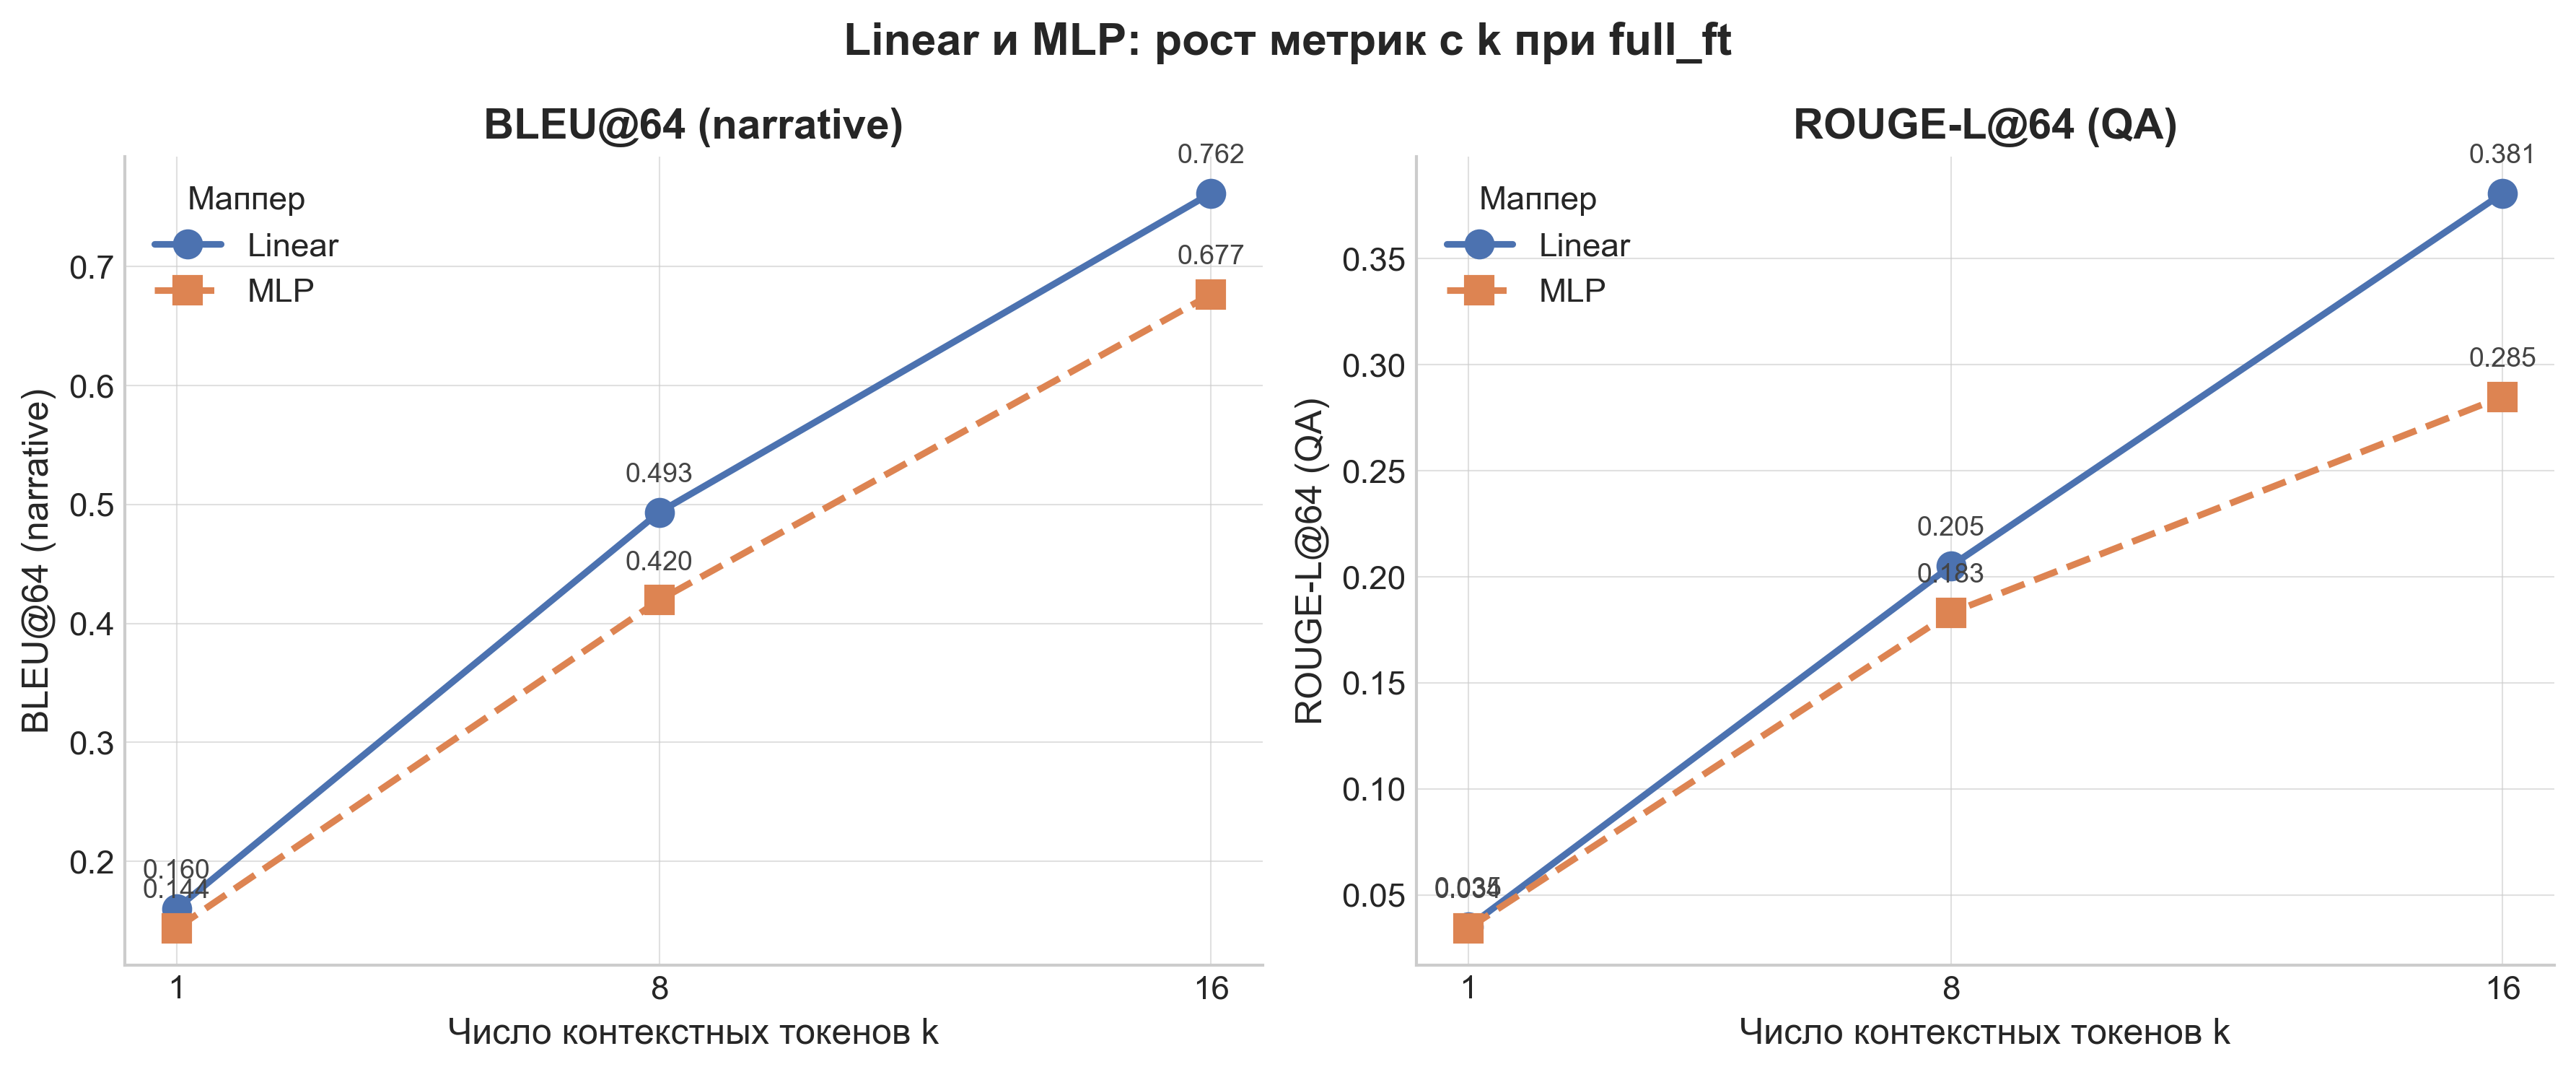

In [22]:
lin_mlp_k = {
    "Linear": {1: "lin_ctx1_full_ft", 8: "lin_ctx8_full_ft", 16: "lin_ctx16_full_ft"},
    "MLP":    {1: "mlp_ctx1_full_ft", 8: "mlp_ctx8_full_ft", 16: "mlp_ctx16_full_ft"},
}
k_vals_ft = [1, 8, 16]
metrics_line = [
    ("val/narrative/bleu@64", "BLEU@64 (narrative)"),
    ("val/qa/rougeL@64",      "ROUGE-L@64 (QA)"),
]

with plt.style.context(PLT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)

    for ax, (metric_key, metric_label) in zip(axes, metrics_line):
        for mapper, k_runs in lin_mlp_k.items():
            vals = [final_metric(k_runs[k], metric_key) for k in k_vals_ft]
            pts  = [(k, v) for k, v in zip(k_vals_ft, vals) if not np.isnan(v)]
            if not pts:
                continue
            kk, vv = zip(*pts)
            ax.plot(kk, vv,
                    color=MAPPER_COLORS[mapper],
                    linestyle=MAPPER_LS[mapper],
                    marker=MAPPER_MARKERS[mapper],
                    markersize=9, linewidth=2.2,
                    label=mapper)
            for k, v in zip(kk, vv):
                ax.annotate(f"{v:.3f}", (k, v), xytext=(0, 10),
                            textcoords="offset points", ha="center",
                            fontsize=9, color="#444")

        ax.set_xticks(k_vals_ft)
        ax.set_xlabel("Число контекстных токенов k", fontsize=FONT_LABEL)
        ax.set_ylabel(metric_label, fontsize=FONT_LABEL)
        ax.set_title(metric_label, fontsize=FONT_TITLE, fontweight="bold")
        ax.tick_params(labelsize=FONT_TICK)
        ax.legend(title="Маппер", fontsize=FONT_TICK, title_fontsize=FONT_TICK,
                  loc="upper left")

    fig.suptitle("Linear и MLP: рост метрик с k при full_ft",
                 fontsize=FONT_TITLE + 1, fontweight="bold")
    plt.tight_layout()
    save_fig(fig, "fig3_5b_kscaling_lin_mlp_full_ft")
    plt.show()

## Рисунок 3.8 — Сложность архитектуры маппера

Сравнение MLP (стандартный) / MLP-36M / TransformerMapper при k=16, map_only.
Штриховка (hatch) обеспечивает различимость при ч/б печати.

  -> fig3_8_complexity_ablation.png / .pdf


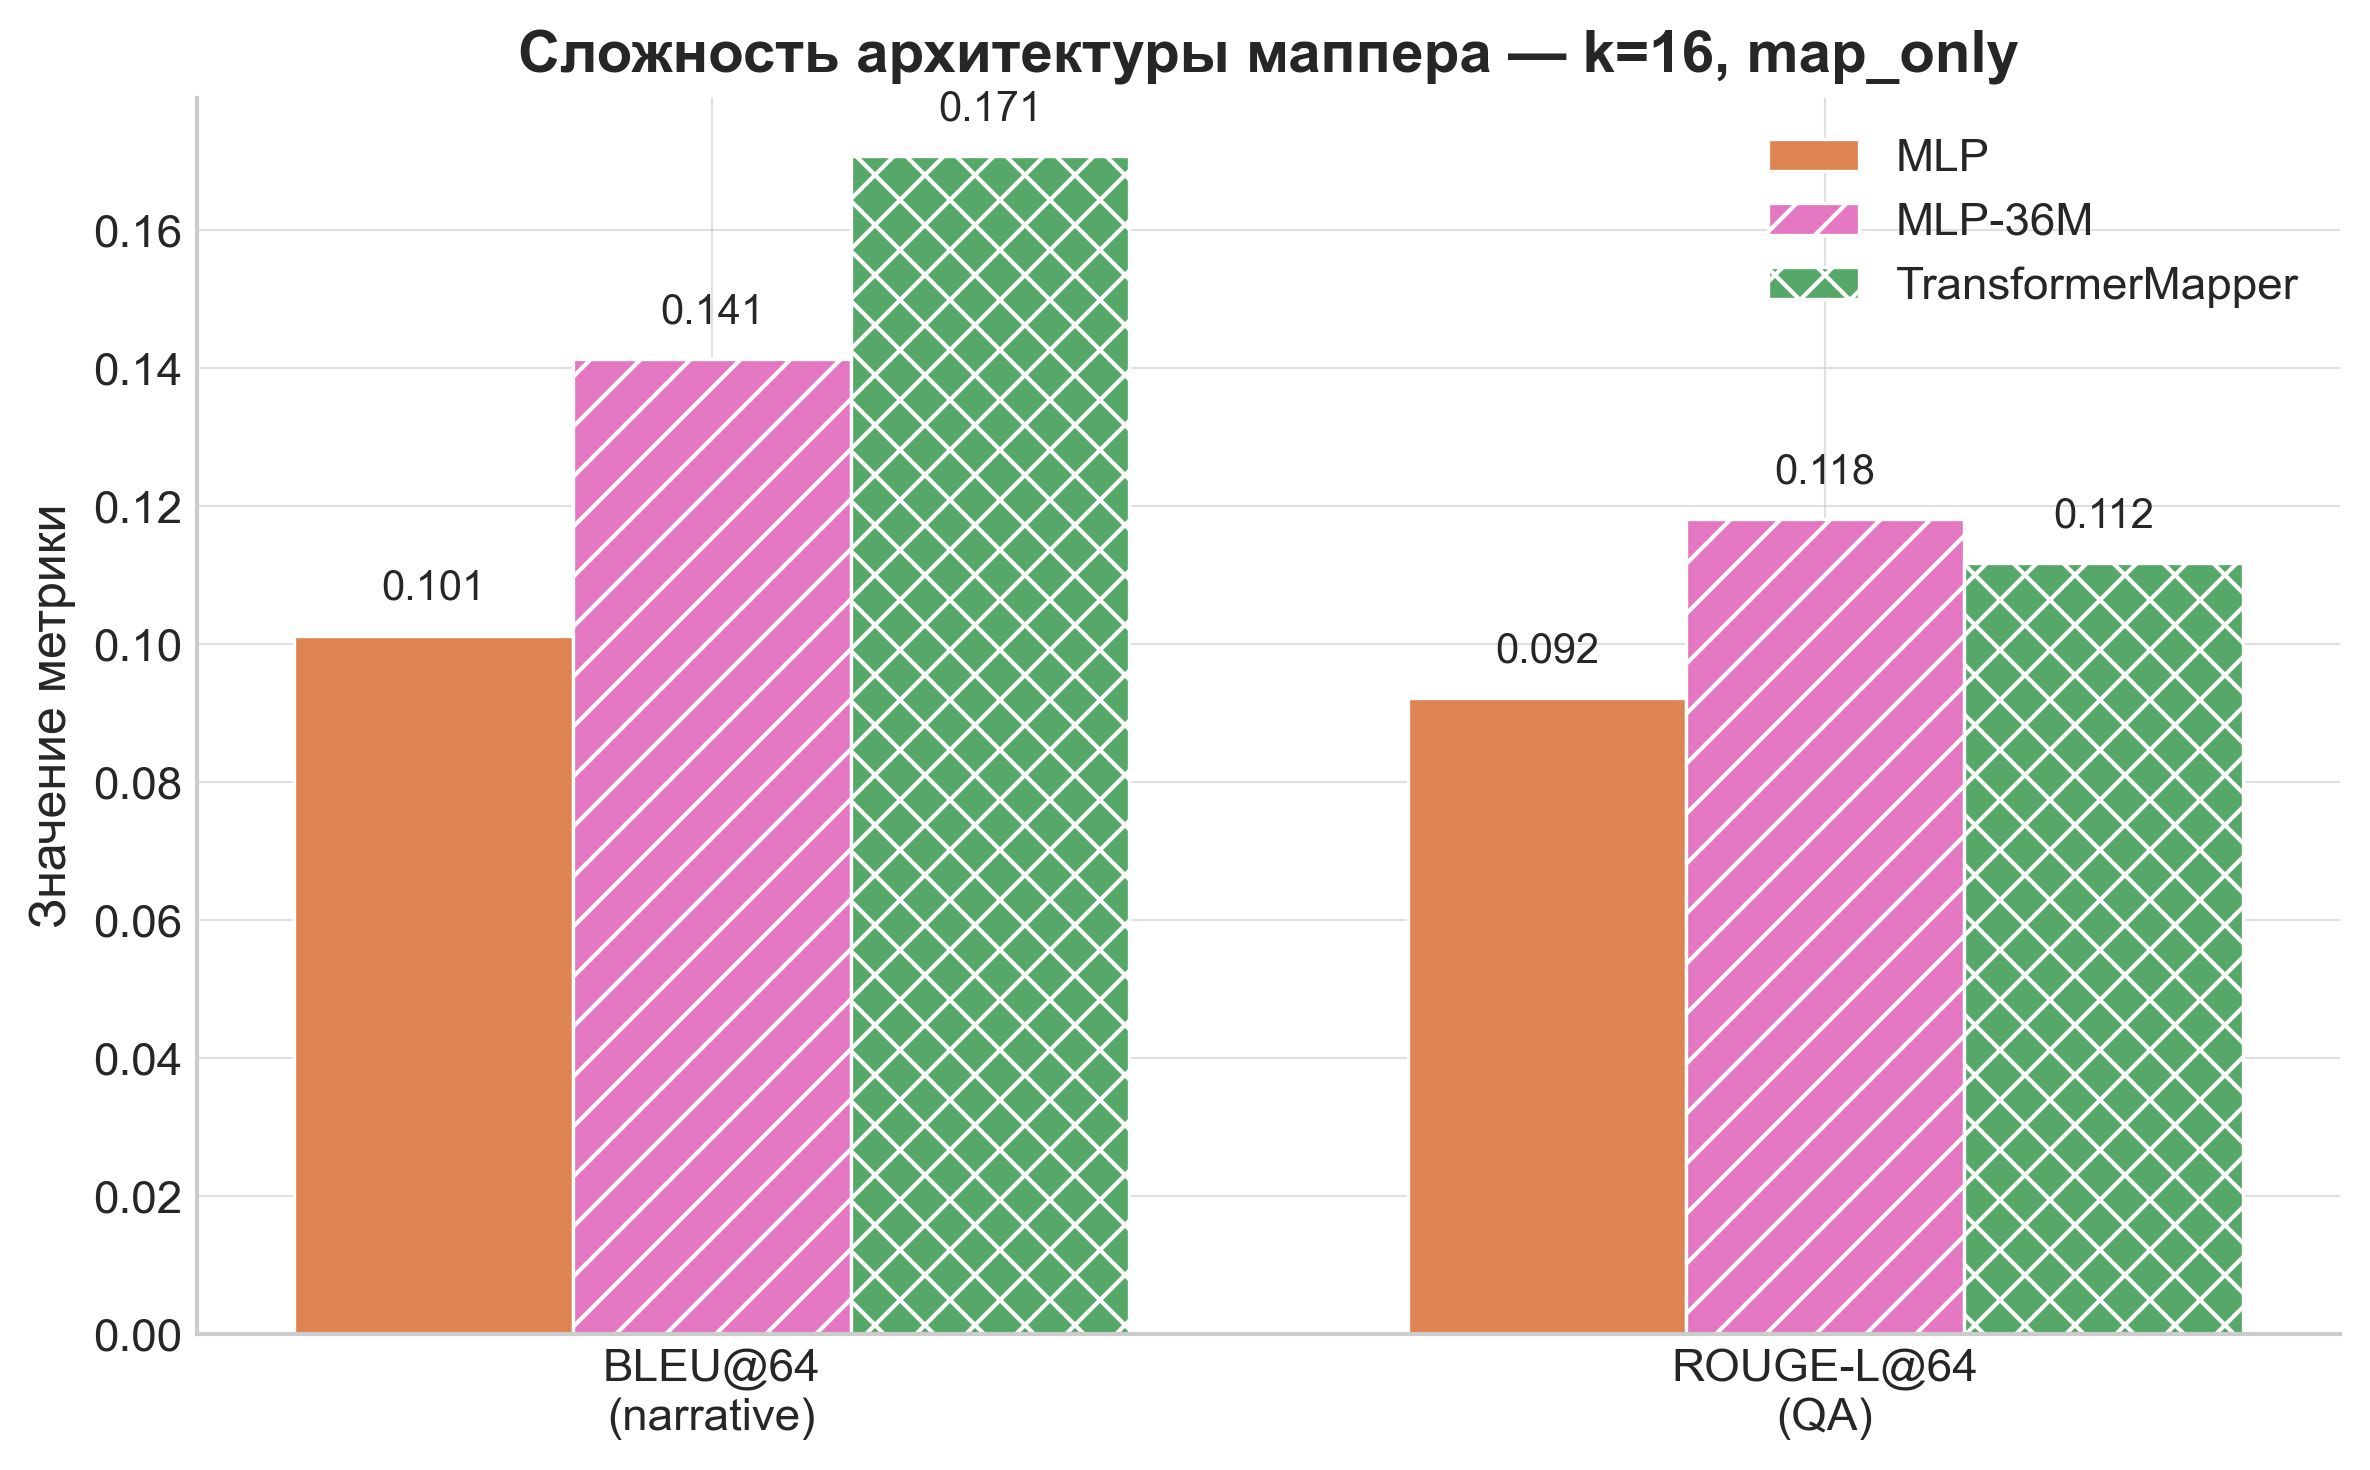

In [12]:
complexity_configs = [
    ("MLP",               "mlp_ctx16_mapper_only"),
    ("MLP-36M",           "mlp_ctx16_mapper_only_36Mparams"),
    ("TransformerMapper", "perceiver_ctx16_mapper_only"),
]
metric_keys  = ["val/narrative/bleu@64", "val/qa/rougeL@64"]
metric_names = ["BLEU@64\n(narrative)", "ROUGE-L@64\n(QA)"]
hatches = ["", "//", "xx"]

x_c = np.arange(len(metric_names))
w_c = 0.25
n_c = len(complexity_configs)

with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)

    for i, (label, run) in enumerate(complexity_configs):
        vals   = [final_metric(run, m) for m in metric_keys]
        offset = (i - (n_c - 1) / 2) * w_c
        bars   = ax.bar(x_c + offset, vals, w_c,
                        label=label,
                        color=MAPPER_COLORS[label],
                        hatch=hatches[i],
                        edgecolor="white", linewidth=0.8)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004,
                        f"{v:.3f}", ha="center", va="bottom",
                        fontsize=FONT_TICK - 1)

    ax.set_xticks(x_c)
    ax.set_xticklabels(metric_names, fontsize=FONT_TICK)
    ax.set_ylabel("Значение метрики", fontsize=FONT_LABEL)
    ax.set_title("Сложность архитектуры маппера — k=16, map_only",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_TICK)
    plt.tight_layout()
    save_fig(fig, "fig3_8_complexity_ablation")
    plt.show()

## PEFT сравнение — map_only / LoRA / soft-prompt

TransformerMapper k=16, LLM=Qwen3-0.6B. Soft-prompt отсутствовал в оригинальном training_viz.ipynb.

  -> fig_peft_comparison.png / .pdf


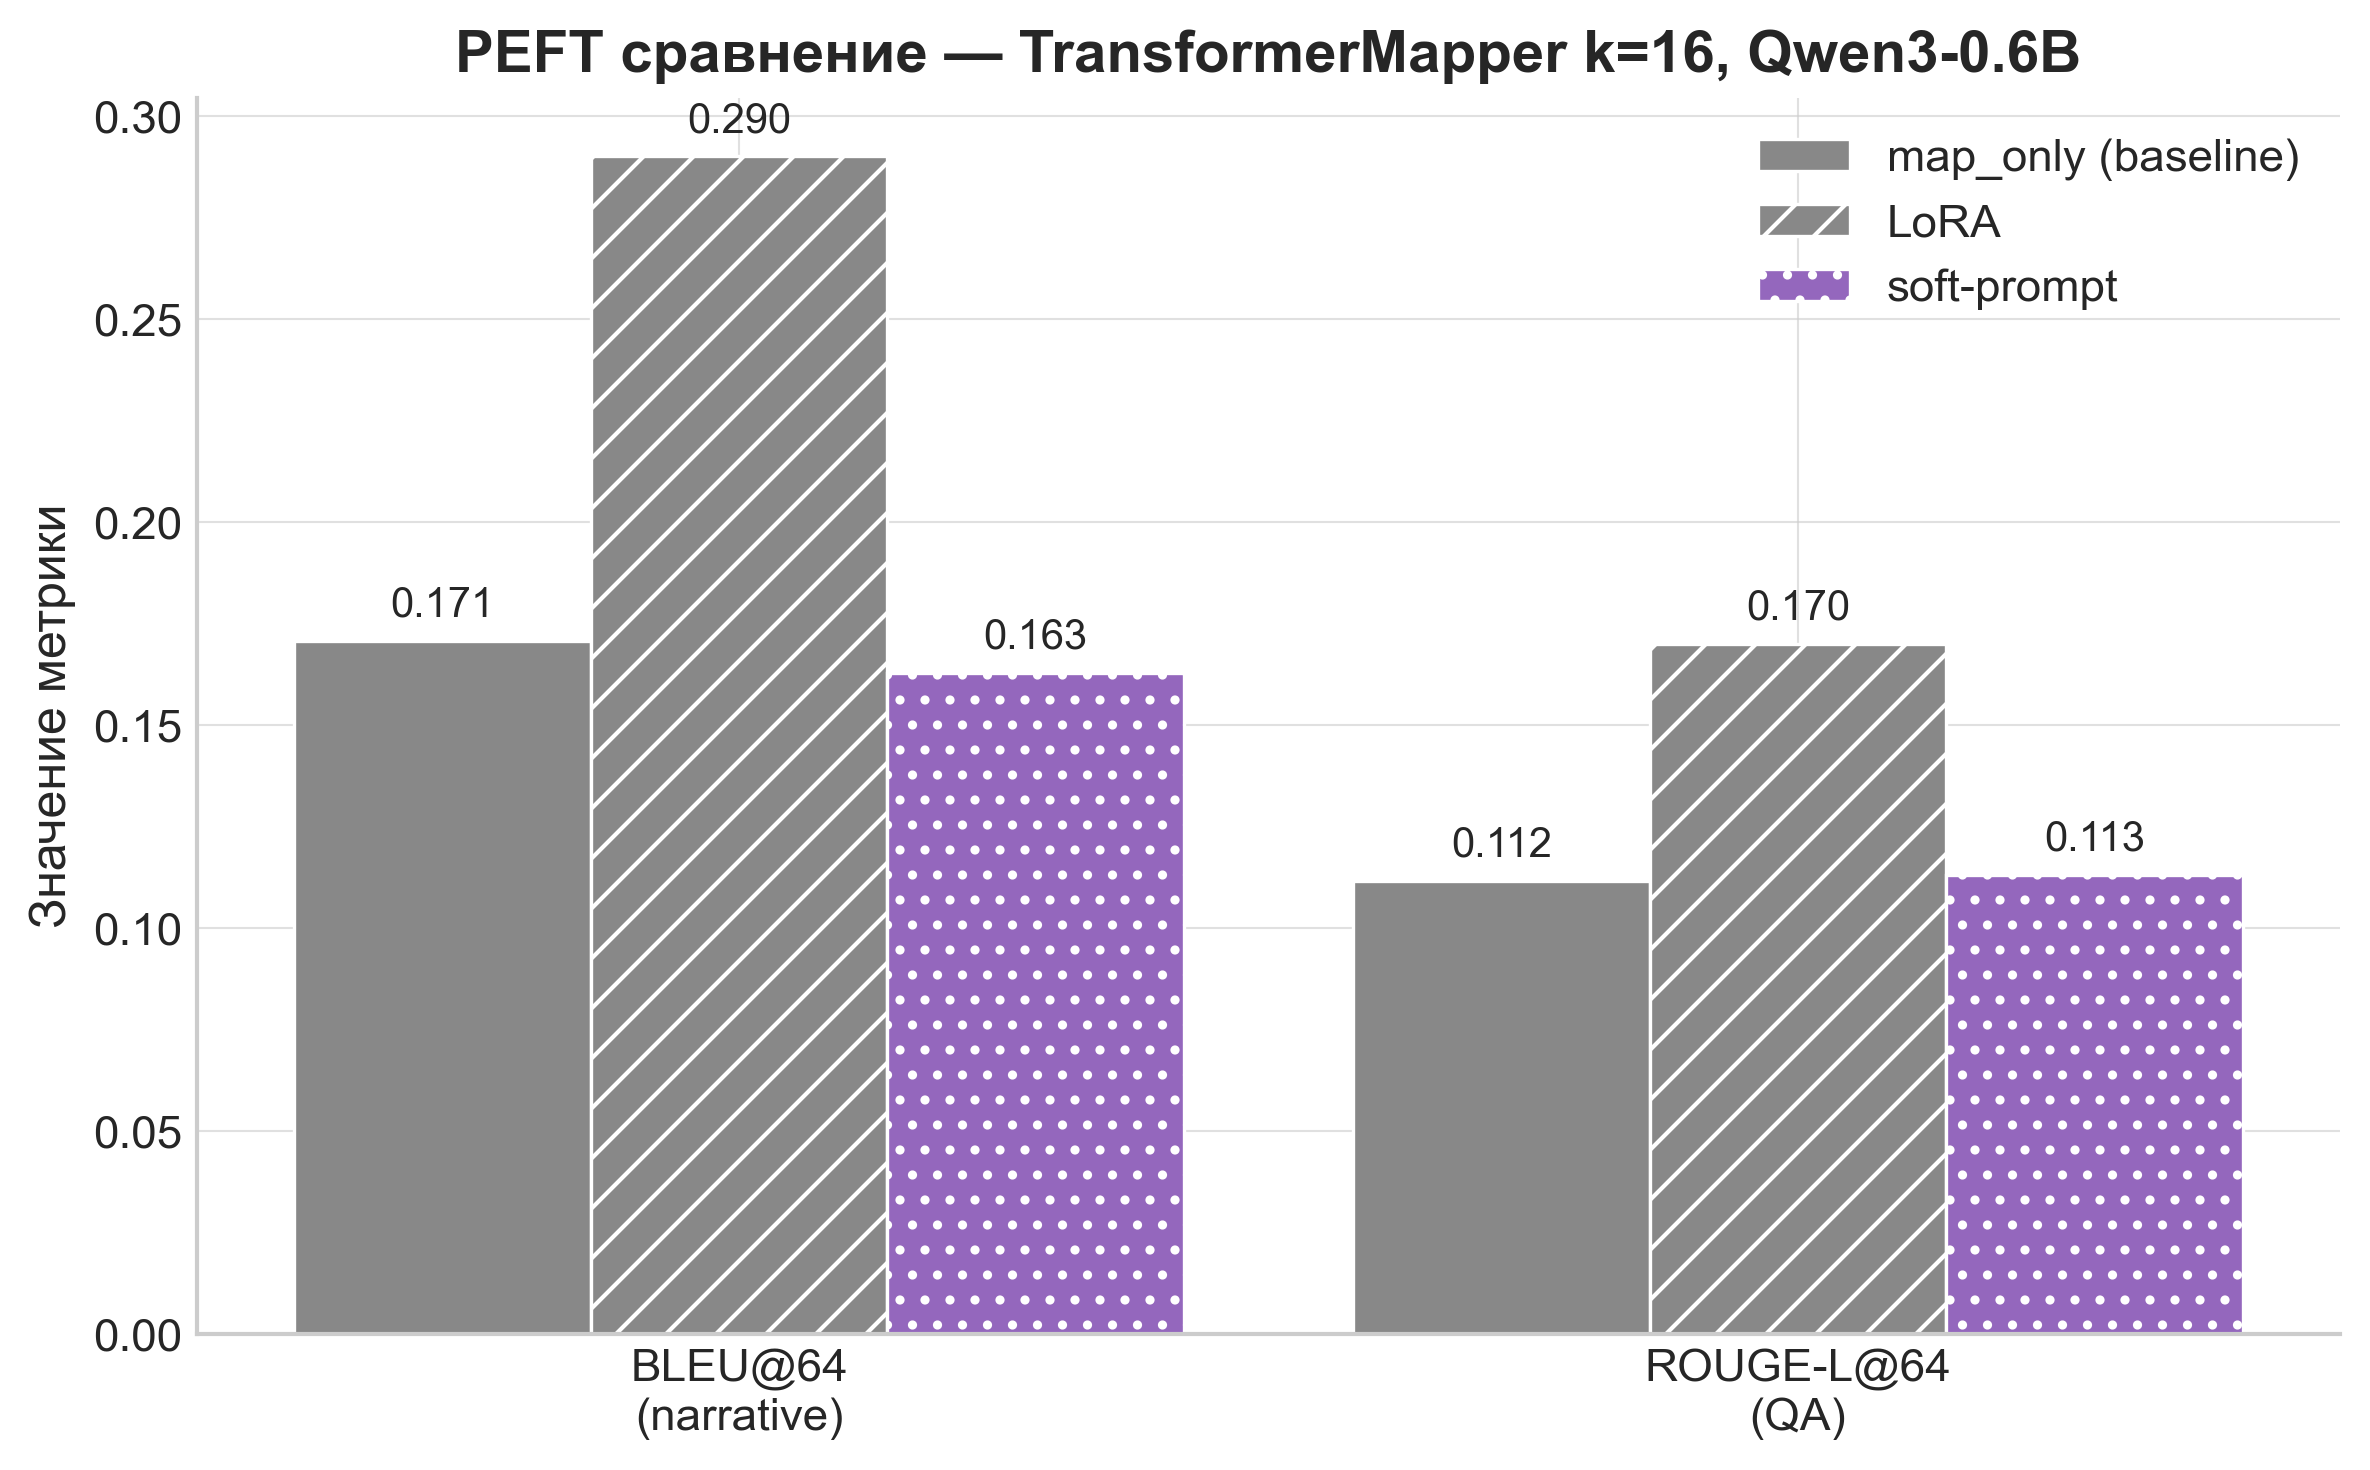

In [15]:
peft_configs = [
    ("map_only (baseline)",    "perceiver_ctx16_mapper_only"),
    ("LoRA",        "lora_qwen_06B_perceiver_ctx16"),
    ("soft-prompt", "prefix_tuning_qwen_06B_perceiver_ctx16"),
]
metric_keys  = ["val/narrative/bleu@64", "val/qa/rougeL@64"]
metric_names = ["BLEU@64\n(narrative)", "ROUGE-L@64\n(QA)"]
hatches_peft = ["", "//", ".."]

x_p = np.arange(len(metric_names))
w_p = 0.28
n_p = len(peft_configs)

with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=DPI)

    for i, (label, run) in enumerate(peft_configs):
        vals   = [final_metric(run, m) for m in metric_keys]
        offset = (i - (n_p - 1) / 2) * w_p
        color  = CONFIG_COLORS.get(label, "#888888")
        bars   = ax.bar(x_p + offset, vals, w_p,
                        label=label, color=color,
                        hatch=hatches_peft[i],
                        edgecolor="white", linewidth=0.8)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004,
                        f"{v:.3f}", ha="center", va="bottom",
                        fontsize=FONT_TICK - 1)

    ax.set_xticks(x_p)
    ax.set_xticklabels(metric_names, fontsize=FONT_TICK)
    ax.set_ylabel("Значение метрики", fontsize=FONT_LABEL)
    ax.set_title("PEFT сравнение — TransformerMapper k=16, Qwen3-0.6B",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_TICK)
    plt.tight_layout()
    save_fig(fig, "fig_peft_comparison")
    plt.show()

## Масштаб LLM — 0.6B / 4B / 8B (+ 8B LoRA)

TransformerMapper k=16. Ожидаемая картина: narrative BLEU убывает с размером модели; QA ROUGE растёт.

  -> fig_llm_scaling.png / .pdf


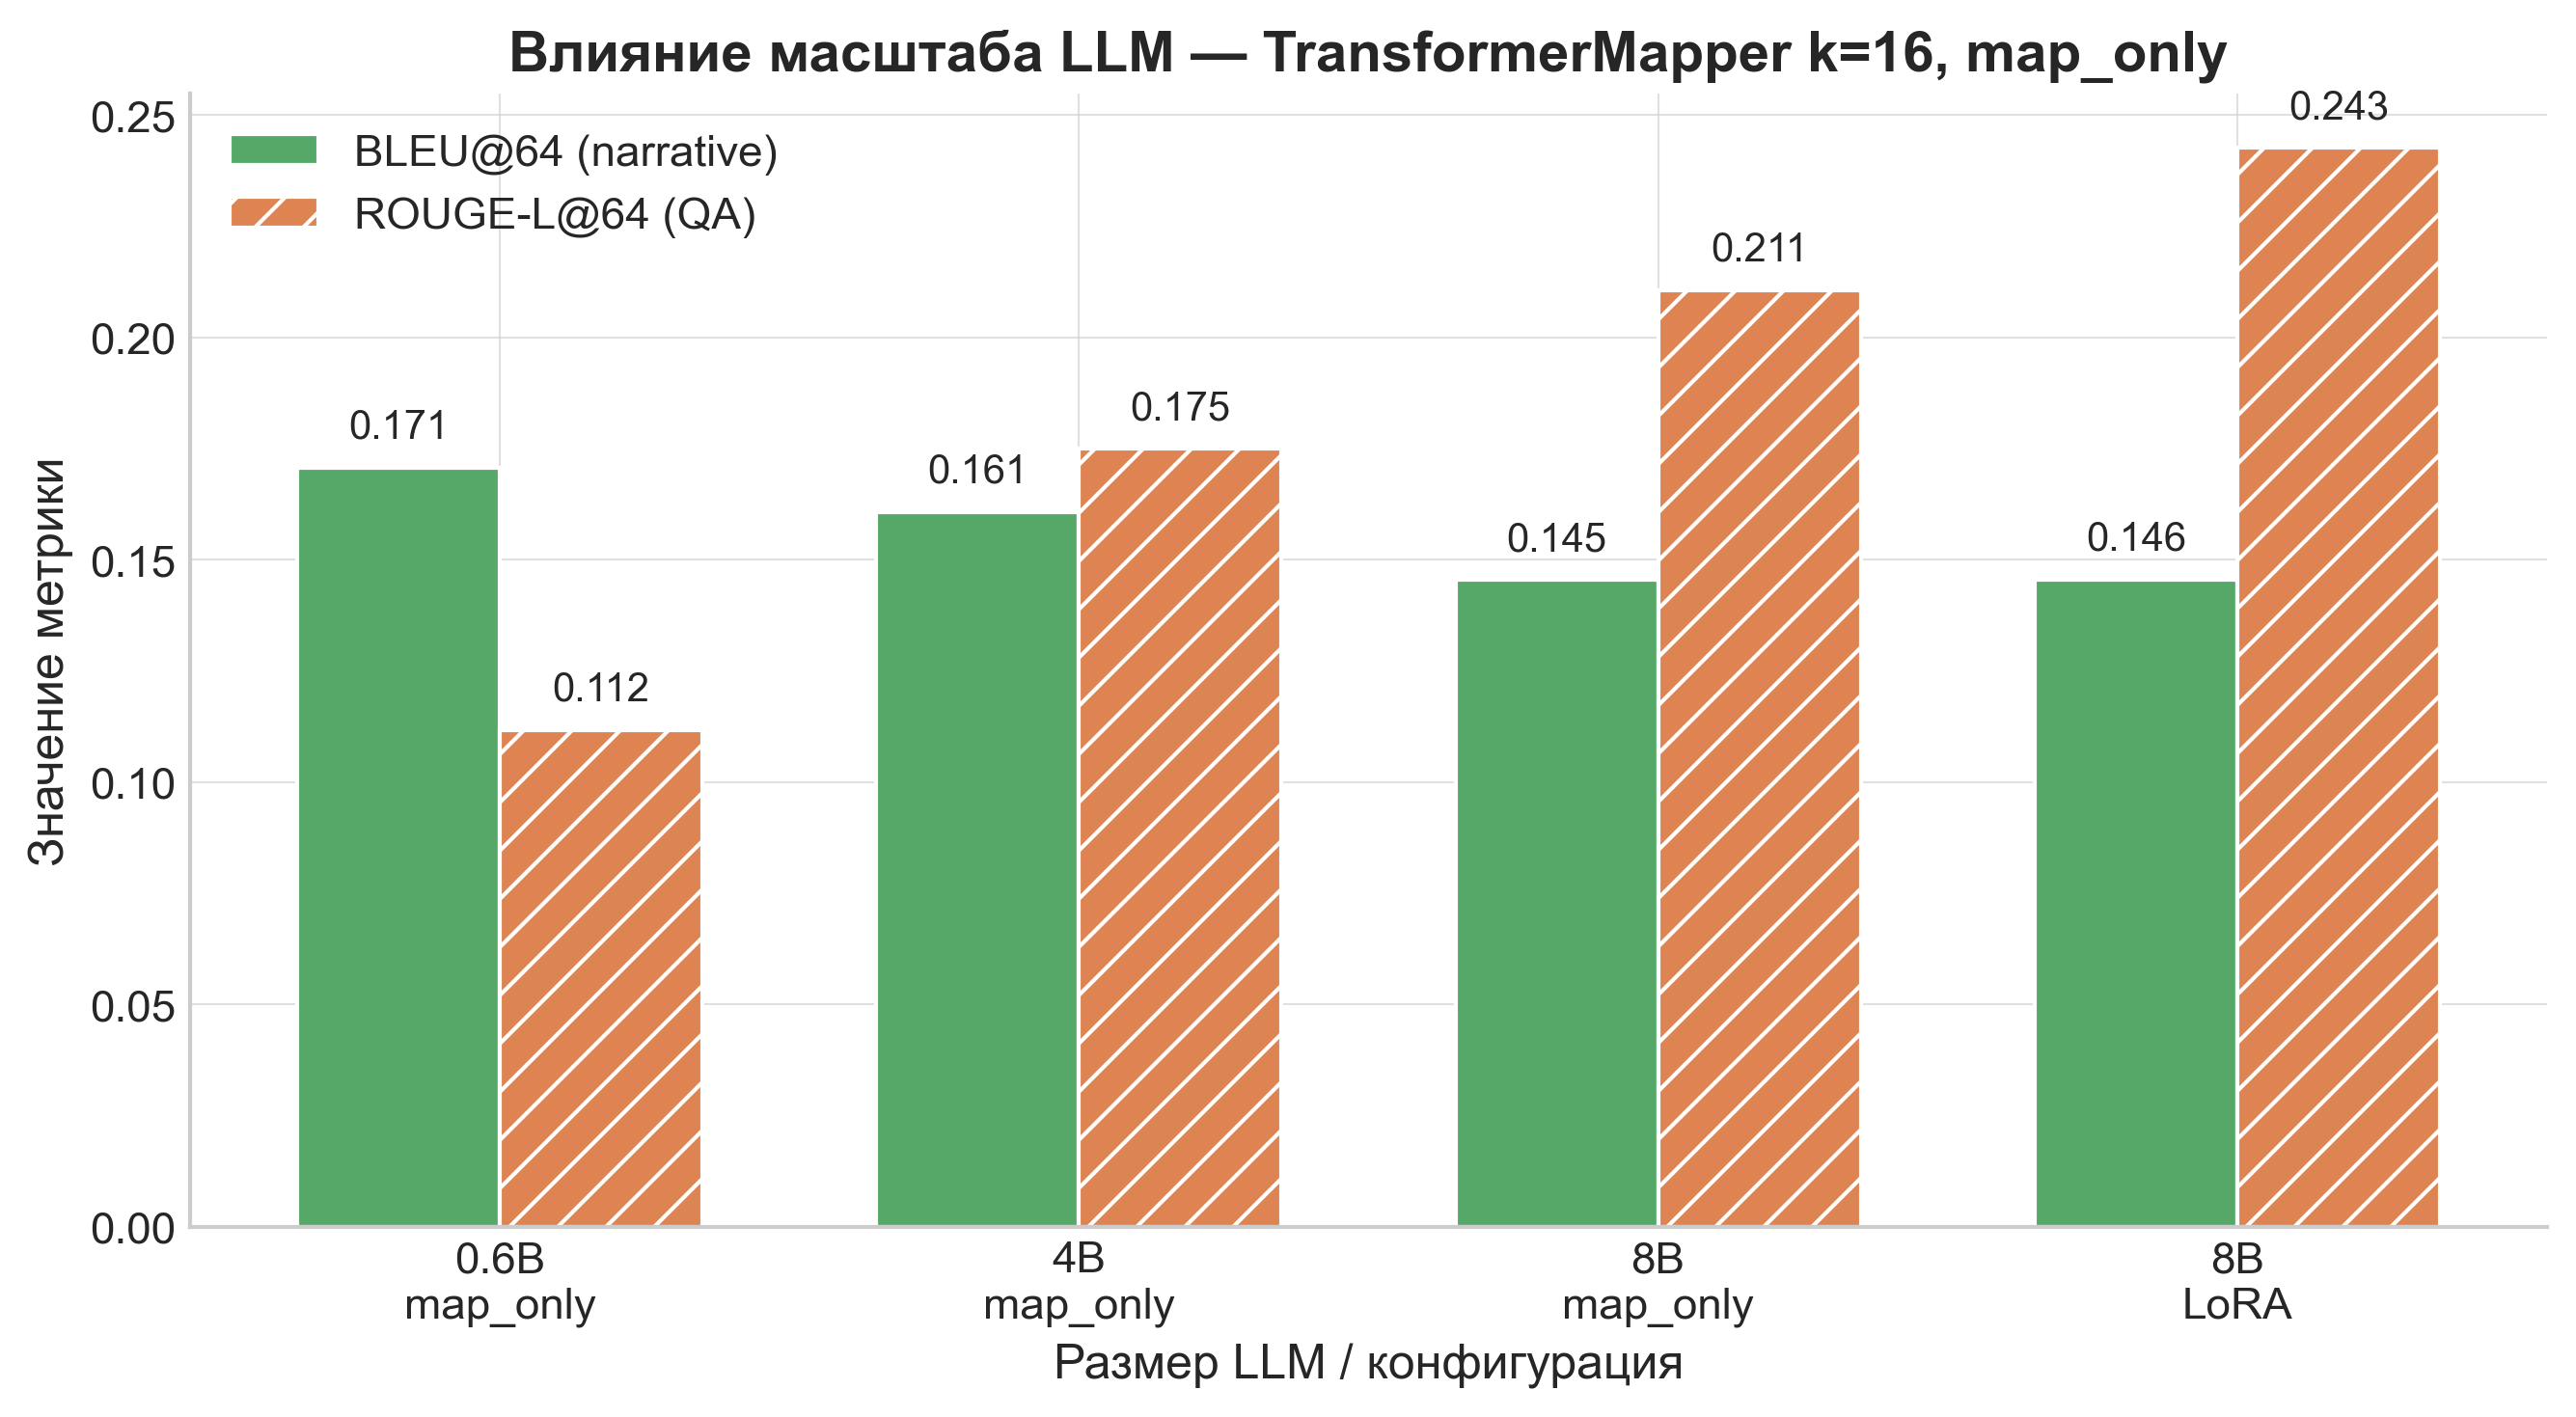

In [16]:
llm_configs = [
    ("0.6B\nmap_only", "perceiver_ctx16_mapper_only"),
    ("4B\nmap_only",   "qwen_4B_perceiver_ctx16_mapper_only"),
    ("8B\nmap_only",   "qwen_8B_perceiver_ctx16_mapper_only"),
    ("8B\nLoRA",       "lora_qwen_8B_perceiver_ctx16_mapper_only"),
]

llm_bleu  = [final_metric(run, "val/narrative/bleu@64")  for _, run in llm_configs]
llm_rouge = [final_metric(run, "val/qa/rougeL@64")       for _, run in llm_configs]
x_l = np.arange(len(llm_configs))
w_l = 0.35

with plt.style.context(PLT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)

    bars_b = ax.bar(x_l - w_l / 2, llm_bleu,  w_l,
                    label="BLEU@64 (narrative)",
                    color=C_TM,  hatch="",   edgecolor="white")
    bars_r = ax.bar(x_l + w_l / 2, llm_rouge, w_l,
                    label="ROUGE-L@64 (QA)",
                    color=C_MLP, hatch="//", edgecolor="white")

    for bars in [bars_b, bars_r]:
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.005, f"{h:.3f}",
                        ha="center", va="bottom", fontsize=FONT_TICK - 1)

    ax.set_xticks(x_l)
    ax.set_xticklabels([lbl for lbl, _ in llm_configs], fontsize=FONT_TICK)
    ax.set_xlabel("Размер LLM / конфигурация", fontsize=FONT_LABEL)
    ax.set_ylabel("Значение метрики", fontsize=FONT_LABEL)
    ax.set_title("Влияние масштаба LLM — TransformerMapper k=16, map_only",
                 fontsize=FONT_TITLE, fontweight="bold")
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_TICK)
    plt.tight_layout()
    save_fig(fig, "fig_llm_scaling")
    plt.show()

## Итог

Ниже — список всех сохранённых файлов и напоминание о рисунках, которые уже есть в `artefacts/figures/`.

## Рисунок 3.? — Сравнение с baseline: full_ft (TransformerMapper k=16) vs Qwen3-0.6B с токенами в промпте

Данные из inference на val-сете. Baseline имеет полный доступ к тексту в промпте;
обученная система видит контекст только через k=16 векторов маппера.

  -> fig_baseline_vs_fullft.png / .pdf


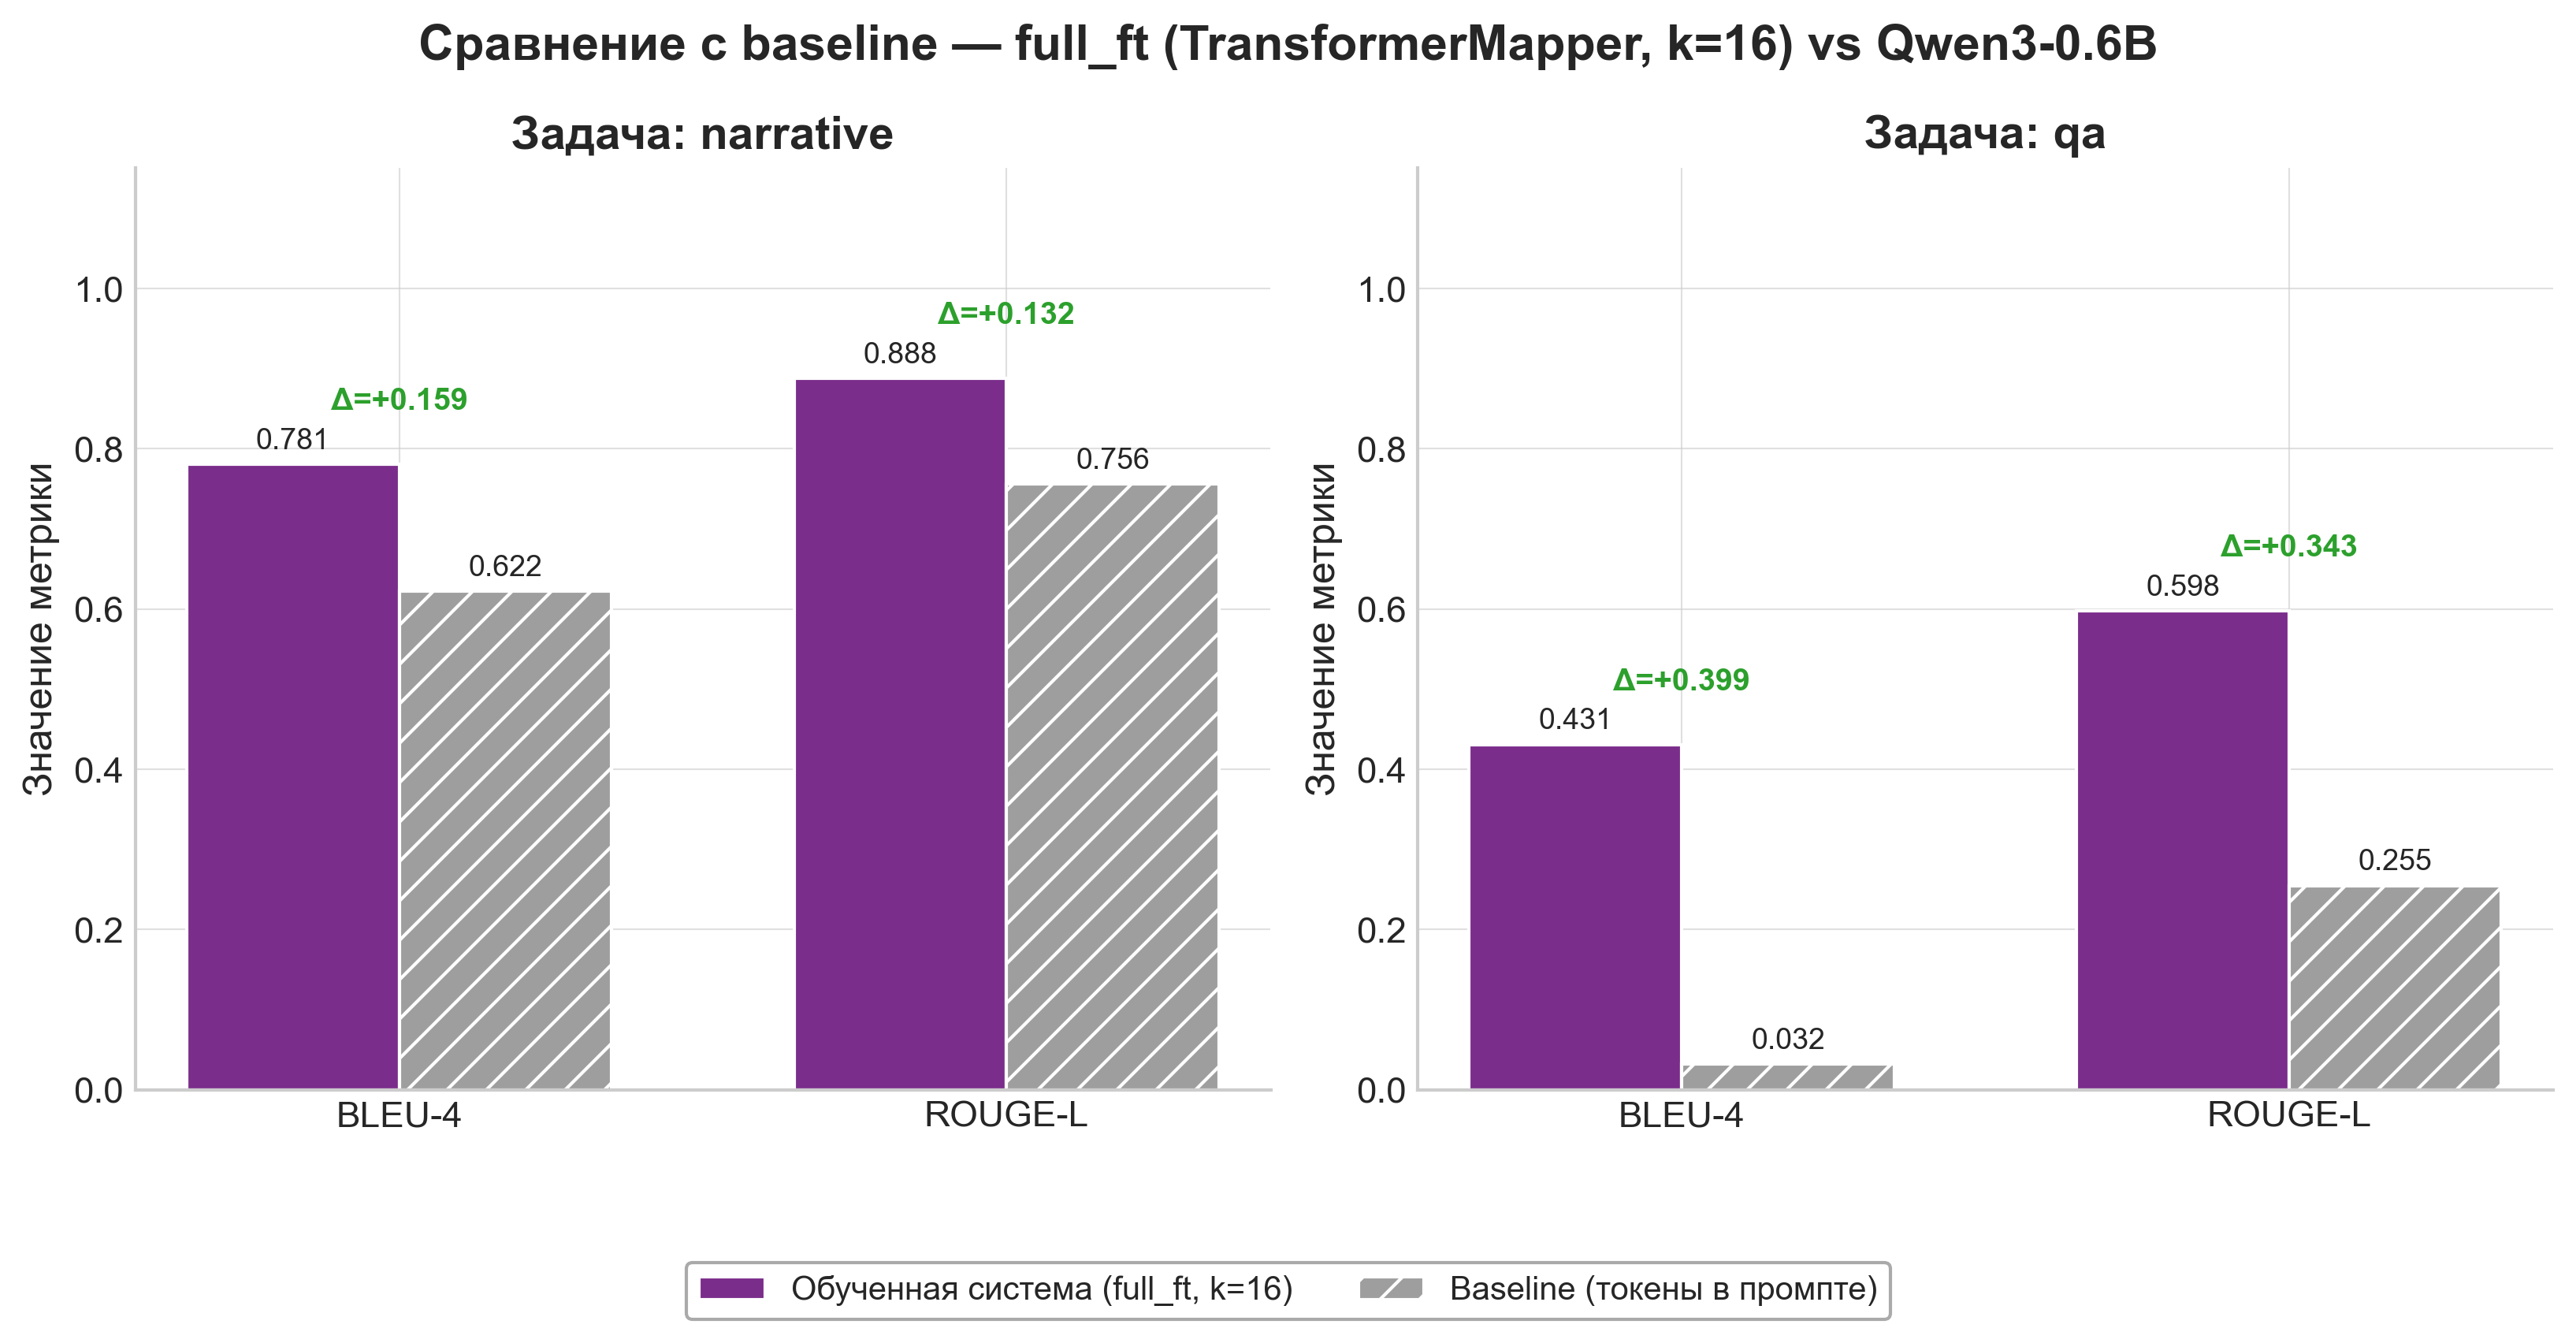

In [28]:
COMPARISON = {
    "narrative": {
        "metrics": ["BLEU-4", "ROUGE-L"],
        "system":   [0.781, 0.888],
        "baseline": [0.622, 0.756],
    },
    "qa": {
        "metrics": ["BLEU-4", "ROUGE-L"],
        "system":   [0.431, 0.598],
        "baseline": [0.032, 0.255],
    },
}

C_SYSTEM   = CONFIG_COLORS["full_ft"]
C_BASELINE = "#9E9E9E"
W = 0.35

with plt.style.context(PLT_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), dpi=DPI)

    for ax, (task, data) in zip(axes, COMPARISON.items()):
        x      = np.arange(len(data["metrics"]))
        sys_v  = data["system"]
        base_v = data["baseline"]

        bars_s = ax.bar(x - W / 2, sys_v,  W,
                        color=C_SYSTEM,   hatch="",   edgecolor="white",
                        label="Обученная система (full_ft, k=16)")
        bars_b = ax.bar(x + W / 2, base_v, W,
                        color=C_BASELINE, hatch="//", edgecolor="white",
                        label="Baseline (токены в промпте)")

        for bar, v in list(zip(bars_s, sys_v)) + list(zip(bars_b, base_v)):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=9)

        for i, (sv, bv) in enumerate(zip(sys_v, base_v)):
            delta = sv - bv
            top   = max(sv, bv) + 0.06
            ax.annotate(f"Δ={delta:+.3f}",
                        xy=(x[i], top), ha="center", va="bottom",
                        fontsize=9.5, fontweight="bold",
                        color="#2ca02c" if delta > 0 else "#d62728")

        ax.set_ylim(0, 1.15)
        ax.set_xticks(x)
        ax.set_xticklabels(data["metrics"], fontsize=FONT_TICK)
        ax.set_ylabel("Значение метрики", fontsize=FONT_LABEL)
        ax.set_title(f"Задача: {task}", fontsize=FONT_TITLE, fontweight="bold")
        ax.tick_params(labelsize=FONT_TICK)

    # Одна общая легенда под обоими субплотами
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2,
               fontsize=FONT_TICK - 1,
               loc="upper center", bbox_to_anchor=(0.5, 0.04),
               frameon=True, facecolor="white", edgecolor="#aaaaaa")

    fig.suptitle("Сравнение с baseline — full_ft (TransformerMapper, k=16) vs Qwen3-0.6B",
                 fontsize=FONT_TITLE + 1, fontweight="bold")
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.16)
    save_fig(fig, "fig_baseline_vs_fullft")
    plt.show()

In [17]:
import os
print("=== Готово ===")
files = sorted(f for f in os.listdir(FIG_DIR) if f.endswith(".png"))
print(f"PNG файлов в artefacts/figures_v2/: {len(files)}")
for f in files:
    print(" ", f)

print("\nРисунки из training_viz.ipynb (artefacts/figures/), используемые как есть:")
REUSE = [
    ("Рис. 3.2  BLEU@64 vs k, map_only",    "3_4_bleu_vs_k_all_mappers_map_only.png"),
    ("Рис. 3.3  ROUGE-L@64 vs k, map_only",  "3_5_rouge_vs_k_all_mappers_map_only.png"),
    ("Рис. 3.5  BLEU@64 vs k, full_ft",      "3_6_bleu_vs_k_all_mappers_full_ft.png"),
    ("Рис. 3.6  ROUGE-L@64 vs k, full_ft",   "3_7_rouge_vs_k_all_mappers_full_ft.png"),
]
fig_dir_old = BASE / "artefacts/figures"
for name, fname in REUSE:
    ok = (fig_dir_old / fname).exists()
    print(f"  {'✓' if ok else '✗'}  {name}  →  {fname}")

=== Готово ===
PNG файлов в artefacts/figures_v2/: 9
  fig3_1_valloss_mapper_only_grid.png
  fig3_2_bleu_vs_k_map_only.png
  fig3_3_rouge_vs_k_map_only.png
  fig3_4_valloss_full_ft_grid.png
  fig3_5_bleu_vs_k_full_ft.png
  fig3_6_rouge_vs_k_full_ft.png
  fig3_8_complexity_ablation.png
  fig_llm_scaling.png
  fig_peft_comparison.png

Рисунки из training_viz.ipynb (artefacts/figures/), используемые как есть:
  ✓  Рис. 3.2  BLEU@64 vs k, map_only  →  3_4_bleu_vs_k_all_mappers_map_only.png
  ✓  Рис. 3.3  ROUGE-L@64 vs k, map_only  →  3_5_rouge_vs_k_all_mappers_map_only.png
  ✓  Рис. 3.5  BLEU@64 vs k, full_ft  →  3_6_bleu_vs_k_all_mappers_full_ft.png
  ✓  Рис. 3.6  ROUGE-L@64 vs k, full_ft  →  3_7_rouge_vs_k_all_mappers_full_ft.png
